In [3]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.transforms as mtransforms
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.image as image
from matplotlib._layoutgrid import plot_children
from matplotlib.transforms import ScaledTranslation
import seaborn as sns
from IPython.core import display

import geopandas as gpd
import shapely
from shapely import LineString, Point, MultiPoint
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import frykit.plot as fplt
from geopy.distance import great_circle
import mapclassify

import networkx as nx
import pycountry

import warnings
import re
import os
import datetime
from collections import defaultdict
import itertools
import json

import scipy
import scipy.stats as stats
from scipy.stats import theilslopes
from scipy.stats import linregress

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statannotations.Annotator import Annotator

import patsy

import pymannkendall as mk
from adjustText import adjust_text

In [4]:
mpl.font_manager.fontManager.addfont(
    "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf",
)

mpl.rcdefaults()

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [222]:
from cnmaps import get_adm_maps, draw_maps, get_adm_names
import cnmaps

# Load data

## load geometry 

In [331]:
nine_line = get_adm_maps(country='CHN', level='国', only_polygon=True)[1]
cn_south_islands = get_adm_maps(province='海南省', level='市', only_polygon=True)[2]

# shapely.to_geojson("../processed_data/shp/nine_line.geojson", engine='GeoJSON')
# cn_south_islands.to_file("../processed_data/shp/cn_south_islands.geojson", engine='GeoJSON')

gpd.GeoSeries([nine_line, cn_south_islands], index=['nine_line', 'south_islands']).to_file(
    "../processed_data/shp/cn_south.geojson", 
    driver="GeoJSON")

/root/zengjf/project/airTraffic/airTrend/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [333]:
cn_south = gpd.read_file("../processed_data/shp/cn_south.geojson")

In [7]:
adm0 = gpd.read_file("../processed_big_data/gadm_level0.gpkg")
adm0_geometry_s = adm0.geometry.simplify(tolerance=0.1)

adm0_s = gpd.GeoDataFrame(adm0, geometry=adm0_geometry_s)

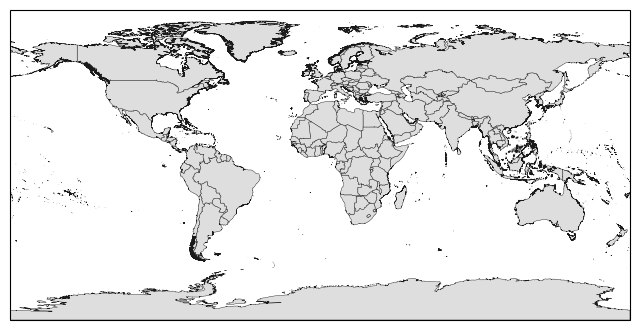

In [338]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
# ax.set_extent([50, 150, -15, 60])
ax.set_global()

ax.add_geometries(adm0_s.geometry, crs=ccrs.PlateCarree(), ec='.1', fc='#DEDEDE', lw=.3)
# draw_maps(get_adm_maps(country='中国', level='国'), color='r', lw=.3)
# ax.add_geometries([nine_line], lw=3, ec='r', fc='none', crs=ccrs.PlateCarree())

ax.add_geometries(cn_south.geometry, lw=1, ec='.1', fc='none', crs=ccrs.PlateCarree())


plt.show()

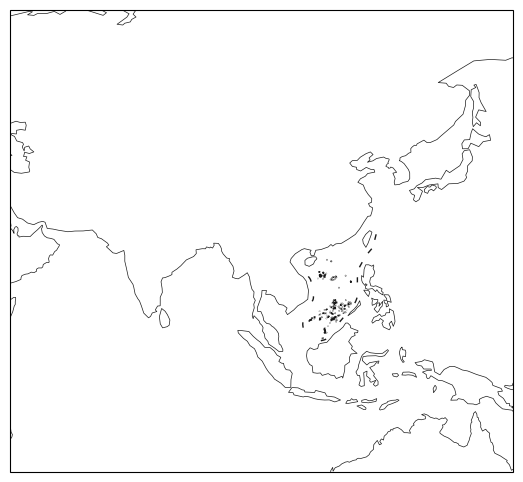

In [352]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.set_extent([50, 150, -15, 60])
# ax.set_global()
ax.add_geometries(cn_south.geometry, lw=1, ec='.1', fc='none', crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5)

plt.show()

## load geographic

In [9]:
iso2_to_iso3 = {c.alpha_2: c.alpha_3 for c in pycountry.countries}
iso3_to_iso2 = {c.alpha_3: c.alpha_2 for c in pycountry.countries}

In [10]:
adm0 = adm0_s[~adm0_s["GID_0"].isin(["ATA"])].copy()
adm0["alpha2"] = adm0["GID_0"].map(lambda x: iso3_to_iso2.get(x))

In [11]:
# population weighted population lat & lon from WorldPop

popd_worldpop = pd.read_csv("../data/PWD_2020_national_1km.csv").copy()
popd_worldpop["iso2"] = popd_worldpop["ISO"].map(iso3_to_iso2)
country_code_to_lonlat = {
    a: (b, c)
    for _, (a, b, c) in popd_worldpop[["iso2", "PWC_Lon", "PWC_Lat"]].iterrows()
}

In [12]:
un_country_df = pd.read_csv("../data/UNSD — Methodology.csv", sep=';', keep_default_na=False)
who_country_df = pd.read_csv("../processed_data/who_country.csv", sep="\t", keep_default_na=False)
oag_country_df = pd.read_csv("../processed_data/oag_country.csv", sep="\t", keep_default_na=False)

In [14]:
un_countries_a2 = un_country_df['ISO-alpha2 Code'].unique().to_numpy() # 248
who_countries_a2 = who_country_df.ISO2.to_numpy()                    # 197
oag_countries_a2 = oag_country_df["Country Code"].unique().to_numpy()  # 241
adm_countries_a2 = adm0['alpha2'].unique().to_numpy()

In [17]:
iso2_to_whoregion = who_country_df.set_index("ISO2")["WHO_region"].to_dict()
iso3_to_whoregion = who_country_df.set_index("ISO3")["WHO_region"].to_dict()

oag_country_name_to_alpha2 = oag_country_df.set_index("Country Name")["Country Code"].to_dict()
alpha2_to_oag_region = oag_country_df.set_index("Country Code")["region_code"].to_dict()
alpha2_to_oag_region2 = oag_country_df.set_index("Country Code")["Region Code"].to_dict()

alpha2_to_gbd = who_country_df.set_index("ISO2")["GBD_location"].to_dict()

In [18]:
np.setdiff1d(adm_countries_a2, un_countries_a2), np.setdiff1d(un_countries_a2, adm_countries_a2)
# TW not in UN Standard country or area codes for statistical use (M49)
# AQ not in modified ADM level0 countries

(array(['TW'], dtype=object), array(['AQ'], dtype=object))

In [19]:
np.setdiff1d(who_countries_a2, un_countries_a2)

array(['TW'], dtype=object)

In [20]:
np.setdiff1d(oag_countries_a2, un_countries_a2)
# history countries in OAG

array(['AN', 'CS', 'TP', 'TW', 'XK', 'YU', 'ZR'], dtype=object)

In [21]:
np.setdiff1d(oag_countries_a2, who_countries_a2)

array(['AI', 'AN', 'AQ', 'AS', 'AW', 'BL', 'BM', 'BQ', 'CC', 'CS', 'CW',
       'CX', 'FK', 'FO', 'GF', 'GI', 'GL', 'GP', 'GU', 'KY', 'LI', 'MF',
       'MP', 'MQ', 'MS', 'NC', 'NF', 'PF', 'PM', 'PR', 'PS', 'RE', 'SH',
       'SX', 'TC', 'TP', 'UM', 'VG', 'VI', 'WF', 'XK', 'YT', 'YU', 'ZR'],
      dtype=object)

In [22]:
oag_history_countries_a2 = ["XK", "TP", "ZR", "YU", "CS", "AN"]  # 6
oag_notin_who_countries_a2 = np.setdiff1d(np.setdiff1d(oag_countries_a2, who_countries_a2), oag_history_countries_a2)

print(oag_history_countries_a2, len(oag_history_countries_a2))
print(oag_notin_who_countries_a2, len(oag_notin_who_countries_a2))

['XK', 'TP', 'ZR', 'YU', 'CS', 'AN'] 6
['AI' 'AQ' 'AS' 'AW' 'BL' 'BM' 'BQ' 'CC' 'CW' 'CX' 'FK' 'FO' 'GF' 'GI'
 'GL' 'GP' 'GU' 'KY' 'LI' 'MF' 'MP' 'MQ' 'MS' 'NC' 'NF' 'PF' 'PM' 'PR'
 'PS' 'RE' 'SH' 'SX' 'TC' 'UM' 'VG' 'VI' 'WF' 'YT'] 38


In [24]:
oag_countries_filter_a2 = np.setdiff1d(
    np.setdiff1d(oag_countries_a2, oag_history_countries_a2), oag_notin_who_countries_a2
)
len(oag_countries_filter_a2)

countries_oag_a3 = np.array([
    pycountry.countries.get(alpha_2=x).alpha_3
    for x in who_countries_a2
])
alpha3_to_oag_region = {
    pycountry.countries.get(alpha_2=k).alpha_3: v
    for k, v in alpha2_to_oag_region.items()
    if k not in oag_history_countries_a2
}

final_countries = np.intersect1d(oag_countries_filter_a2, who_countries_a2)
final_countries_alpha2 = final_countries
final_countries_alhpa3 = np.array([iso2_to_iso3[x] for x in final_countries_alpha2])
print(len(final_countries))

# iaco_states = np.load("../processed_data/icao_countries.npy")
# world = gpd.read_file("../processed_data/shp/natural_earth_countries.geojson")

197


In [25]:
countries = np.setdiff1d(final_countries, ["AD", "LI", "SM"])
countries.shape

(195,)

In [38]:
countries_a2 = countries
countries_a3 = np.array([iso2_to_iso3[x] for x in countries_a2])

In [29]:
un_country2code = un_country_df.set_index("Country or Area")["ISO-alpha2 Code"].to_dict()
un_country2code["China, Hong Kong SAR"] = "HK"
un_country2code["China, Macao SAR"] = "MO"
un_country2code["Côte d'Ivoire"] = "CI"
un_country2code["Republic of South Sudan"] = "SS"
un_country2code["Reunion"] = "RE"
un_country2code["Saint Helena ex. dep."] = "SH"
# un_country2code["Saint Helena: Ascension"] = 'SH'
# un_country2code["Saint Helena: Tristan da Cunha"] = 'SH'
un_country2code["Saint-Martin (French part)"] = "MF"

country2region = un_country_df.set_index("ISO-alpha2 Code")["Sub-region Name"].to_dict()
country2region["TW"] = "Eastern Asia"
country2region["ZR"] = "Sub-Saharan Africa"

region2map = {
    "Sub-Saharan Africa": "Sub-Saharan Africa",
    "Northern Africa": "Northern Africa",
    "Western Asia": "Western Asia",
    "Central Asia": "Central and Southern Asia",
    "Southern Asia": "Central and Southern Asia",
    "Eastern Asia": "Estern and South-Eastern Asia",
    "South-eastern Asia": "Estern and South-Eastern Asia",
    "Latin America and the Caribbean": "Latin America and the Caribbean",
    "Australia and New Zealand": "Oceania",
    "Polynesia": "Oceania islands",
    "Melanesia": "Oceania islands",
    "Micronesia": "Oceania islands",
    "Southern Europe": "Europe",
    "Western Europe": "Europe",
    "Eastern Europe": "Europe",
    "Northern Europe": "Europe",
    "Northern America": "Northern America",
}


region2map2 = {
    "Sub-Saharan Africa": "Africa",
    "Northern Africa": "Africa",
    "Western Asia": "Middle East",
    "Central Asia": "Asia-Pacific",
    "Southern Asia": "Asia-Pacific",
    "Eastern Asia": "Asia-Pacific",
    "South-eastern Asia": "Asia-Pacific",
    "Latin America and the Caribbean": "Latin America and the Caribbean",
    "Australia and New Zealand": "Asia-Pacific",
    "Polynesia": "Asia-Pacific",
    "Melanesia": "Asia-Pacific",
    "Micronesia": "Asia-Pacific",
    "Southern Europe": "Europe",
    "Western Europe": "Europe",
    "Eastern Europe": "Europe",
    "Northern Europe": "Europe",
    "Northern America": "Northern America",
}

alpha2_to_country = un_country_df.set_index("ISO-alpha2 Code")[
    "Country or Area"
].to_dict()

country2region2 = {k: region2map.get(v) for k, v in country2region.items()}
country2region3 = {k: region2map2.get(v) for k, v in country2region.items()}

ISO-3166 codes: 249  
UN states: 193  
WHO countries: all member states of the United Nations except for Liechtenstein (192), plus Cook Islands and Niue.

## load airports

In [31]:
airports = pd.read_csv(
    "../processed_data/airports.csv", sep="\t", keep_default_na=False
)
airports["OAG_region"] = airports["ISO2"].map(lambda x: alpha2_to_oag_region.get(x))

airport_to_oag_region = airports.set_index("IATA")["OAG_region"].to_dict()
airport_to_alpha2 = airports.set_index("IATA")["ISO2"].to_dict()
airport_to_alpha3 = airports.set_index("IATA")["ISO3"].to_dict()

airport_to_alpha2["INO"] = "CD"
airport_to_alpha3["INO"] = "COD"

airport_code_to_lonlat = {
    a: (c, b) for a, b, c in airports[["IATA", "lat", "lon"]].values
}

In [32]:
airport_geometry = [Point(xy) for xy in zip(airports["lon"], airports["lat"])]
airport_geodata = gpd.GeoDataFrame(airports, crs="EPSG:4326", geometry=airport_geometry)

## load population

In [41]:
un_pop = pd.read_csv(
    "../data/RAW/WPP2024_Demographic_Indicators_Medium.csv",
    keep_default_na=False,
    na_values=[""],
    low_memory=False,
)
un_pop = un_pop.query("ISO3_code in @countries_a3 and Time > 2010 and Time <= 2024")[
    ["ISO3_code", "ISO2_code", "Location", "Time", "TPopulation1July"]
]

un_pop_w = pd.pivot_table(
    data=un_pop, values="TPopulation1July", index="Time", columns="ISO2_code"
).reindex(columns=countries)

un_pop_w.head()

ISO2_code,AE,AF,AG,AL,AM,AO,AR,AT,AU,AZ,...,UZ,VC,VE,VN,VU,WS,YE,ZA,ZM,ZW
Time,,,,,,,,,,,,,,,,,,,,,
2011,7199.424,29347.708,86.332,2911.504,2923.270,24218.352,41730.660,8393.270,22479.775,9256.150,...,28823.196,109.348,29185.212,88468.314,243.474,194.713,27582.897,52995.205,14437.796,13595.424
2012,7497.118,30560.034,87.260,2910.004,2922.528,25177.394,42161.722,8431.601,22852.644,9376.180,...,29261.903,108.736,29553.826,89510.356,248.884,196.498,28433.647,53782.566,14913.629,13817.887
2013,7831.847,31622.704,88.064,2907.573,2922.518,26165.620,42582.455,8481.406,23236.270,9504.409,...,29724.065,108.135,29912.198,90573.104,254.482,198.268,29312.952,54678.792,15398.997,14013.808
2014,8236.874,32792.523,88.765,2903.750,2922.422,27160.769,43024.071,8547.818,23595.601,9631.138,...,30222.994,107.535,30254.079,91679.578,260.240,200.037,30226.309,55594.838,15895.315,14207.358
2015,8674.633,33831.764,89.409,2898.632,2921.177,28157.798,43477.012,8644.038,23948.002,9752.850,...,30749.346,106.960,30573.972,92823.254,266.101,201.782,31159.379,56723.537,16399.089,14399.013


# load OAG traffic data

## airport pair

In [ ]:
# all_traffic_monthly = pd.read_csv("../processed_big_data/all_traffic_monthly_update.csv", keep_default_na=False)
all_traffic_monthly = pd.read_csv(
    "../processed_big_data/all_traffic_monthly_20250416.csv", keep_default_na=False
)

all_traffic_monthly["dep_country"] = all_traffic_monthly["dep_airport"].map(
    airport_to_alpha2
)
all_traffic_monthly["arr_country"] = all_traffic_monthly["arr_airport"].map(
    airport_to_alpha2
)
all_traffic_monthly["year"] = all_traffic_monthly["time"] // 100

all_traffic_monthly["time2"] = pd.to_datetime(
    all_traffic_monthly["time"], format="%Y%m"
)
all_traffic_monthly.loc[
    all_traffic_monthly["dep_country"] == all_traffic_monthly["arr_country"], "type"
] = "national"
all_traffic_monthly.loc[
    all_traffic_monthly["dep_country"] != all_traffic_monthly["arr_country"], "type"
] = "international"

all_traffic_monthly.head()

In [71]:
# keep all airports
all_traffic_monthly = pd.read_csv(
    "../processed_big_data/all_traffic_monthly_20250416.csv", keep_default_na=False
)

# just airports in selected countries
# all_traffic_monthly = pd.read_csv("../processed_big_data/all_traffic_monthly_update.csv", keep_default_na=False)


all_traffic_monthly["dep_country"] = all_traffic_monthly["dep_airport"].map(
    airport_to_alpha2
)
all_traffic_monthly["arr_country"] = all_traffic_monthly["arr_airport"].map(
    airport_to_alpha2
)
all_traffic_monthly["year"] = all_traffic_monthly["time"] // 100

all_traffic_monthly["time2"] = pd.to_datetime(
    all_traffic_monthly["time"], format="%Y%m"
)
all_traffic_monthly.loc[
    all_traffic_monthly["dep_country"] == all_traffic_monthly["arr_country"], "type"
] = "national"
all_traffic_monthly.loc[
    all_traffic_monthly["dep_country"] != all_traffic_monthly["arr_country"], "type"
] = "international"

all_traffic_monthly.head()

,time,dep_airport,arr_airport,traffic,dep_country,arr_country,year,time2,type
0,201101,AAA,BOB,7,PF,PF,2011,2011-01-01,national
1,201101,AAA,MKP,196,PF,PF,2011,2011-01-01,national
2,201101,AAA,PPT,207,PF,PF,2011,2011-01-01,national
3,201101,AAA,RFP,5,PF,PF,2011,2011-01-01,national
4,201101,AAC,AMM,2,EG,JO,2011,2011-01-01,international


In [79]:
# all_traffic_yearly = all_traffic_monthly.groupby(['year', 'dep_airport', 'arr_airport'], as_index=False)['traffic'].sum()
# all_traffic_yearly['dep_country'] = all_traffic_yearly['dep_airport'].map(airport_to_alpha2)
# all_traffic_yearly['arr_country'] = all_traffic_yearly['arr_airport'].map(airport_to_alpha2)
# all_traffic_yearly['dep_region'] = all_traffic_yearly['dep_country'].map(country2region3)
# all_traffic_yearly['arr_region'] = all_traffic_yearly['arr_country'].map(country2region3)

# all_traffic_yearly.loc[all_traffic_yearly['dep_country'] == all_traffic_yearly['arr_country'], 'type'] = 'national'
# all_traffic_yearly.loc[all_traffic_yearly['dep_country'] != all_traffic_yearly['arr_country'], 'type'] = 'international'

# all_traffic_yearly.loc[all_traffic_yearly['dep_region'] == all_traffic_yearly['arr_region'], 'type2'] = 'intra-region'
# all_traffic_yearly.loc[all_traffic_yearly['dep_region'] != all_traffic_yearly['arr_region'], 'type2'] = 'extra-region'
# all_traffic_yearly.loc[all_traffic_yearly['type']=='national', 'type2'] = 'national'

# all_traffic_yearly['routes_group'] = all_traffic_yearly[['dep_region', 'arr_region']].apply(lambda x: " <-> ".join(sorted(x)), axis=1)
# all_traffic_yearly['airports_group'] = all_traffic_yearly[['dep_airport', 'arr_airport']].apply(lambda x: " <-> ".join(sorted(x)), axis=1)
# all_traffic_yearly['country_group'] = all_traffic_yearly[['dep_country', 'arr_country']].apply(lambda x: " <-> ".join(sorted(x)), axis=1)

# gcd = all_traffic_yearly[['dep_airport', 'arr_airport']].drop_duplicates()
# gcd['gcd'] = gcd.apply(
#     lambda row: great_circle(
#         airport_code_to_lonlat[row['dep_airport']][::-1],
#         airport_code_to_lonlat[row['arr_airport']][::-1]).kilometers,
#     axis=1)

# # gcd = pd.read_csv("./processed_big_data/gcd.csv", sep='\t')
# all_traffic_yearly = pd.merge(all_traffic_yearly, gcd, on=['dep_airport', 'arr_airport'], how='left')

# all_traffic_yearly.to_csv("../processed_big_data/all_traffic_yearly_update.csv", index=False)
all_traffic_yearly = pd.read_csv(
    "../processed_big_data/all_traffic_yearly_update.csv", keep_default_na=False
)
all_traffic_yearly.head()

,year,dep_airport,arr_airport,traffic,dep_country,arr_country,dep_region,arr_region,type,type2,routes_group,airports_group,country_group,gcd
0,2011,AAA,AAB,499,PF,AU,Asia-Pacific,Asia-Pacific,international,intra-region,Asia-Pacific <-> Asia-Pacific,AAA <-> AAB,AU <-> PF,7544.903298
1,2011,AAA,BOB,49,PF,PF,Asia-Pacific,Asia-Pacific,national,national,Asia-Pacific <-> Asia-Pacific,AAA <-> BOB,PF <-> PF,671.641751
2,2011,AAA,HHZ,121,PF,PF,Asia-Pacific,Asia-Pacific,national,national,Asia-Pacific <-> Asia-Pacific,AAA <-> HHZ,PF <-> PF,308.036810
3,2011,AAA,HOI,2,PF,PF,Asia-Pacific,Asia-Pacific,national,national,Asia-Pacific <-> Asia-Pacific,AAA <-> HOI,PF <-> PF,490.060190
4,2011,AAA,MKP,1406,PF,PF,Asia-Pacific,Asia-Pacific,national,national,Asia-Pacific <-> Asia-Pacific,AAA <-> MKP,PF <-> PF,214.676376


In [83]:
# check two datasets
all_traffic_monthly['traffic'].sum(), all_traffic_yearly['traffic'].sum()

(np.int64(41223813001), np.int64(41223813001))

In [84]:
# f =open("./results/traffic_summary.csv", "w")
# f.write("year\tairports\tOD_airports\tcountries\tOD_countries\tpax\n")

print("year\tairports\tOD_airports\tcountries\tOD_countries\tpax")
for year in range(2011, 2025):
    sub = all_traffic_yearly[all_traffic_yearly["year"] == year]
    n_airprots = np.union1d(
        sub["dep_airport"].unique(), sub["arr_airport"].unique()
    ).shape[0]
    n_pairs = sub["airports_group"].unique().shape[0]
    n_pax = sub["traffic"].sum()

    # sub_ = sub[sub['traffic'] >= 10]
    sub_ = sub
    n_airprots_ = np.union1d(
        sub_["dep_country"].unique(), sub_["arr_country"].unique()
    ).shape[0]
    n_pairs_ = sub_["country_group"].unique().shape[0]
    # n_pax_ = sub_['traffic'].sum()

    print(
        f"{year}\t{n_airprots}\t{n_pairs:,.0f}\t{n_airprots_:,.0f}\t{n_pairs_:,.0f}\t{n_pax:,.0f}"
    )
    # f.write(f"{year}\t{n_airprots}\t{n_pairs}\t{n_airprots_}\t{n_pairs_}\t{n_pax}\n")

# f.close()

year	airports	OD_airports	countries	OD_countries	pax
2011	3911	605,835	228	19,164	2,336,833,628
2012	3880	612,237	228	19,380	2,441,297,083
2013	3943	602,754	228	19,345	2,628,270,111
2014	3948	612,041	228	19,360	2,791,965,286
2015	3932	611,725	228	19,441	2,979,438,238
2016	3986	614,495	228	19,429	3,186,897,992
2017	4149	623,249	229	19,559	3,449,922,369
2018	4404	635,887	229	19,606	3,679,904,555
2019	4755	644,257	229	19,727	3,788,246,794
2020	4766	480,590	229	17,706	1,648,700,186
2021	4743	429,988	229	16,831	1,989,349,715
2022	4808	551,242	228	18,871	2,795,035,493
2023	4240	587,748	228	19,393	3,601,205,353
2024	4354	597,733	229	19,554	3,906,746,198


## country pair

In [85]:
national_traffic_net = all_traffic_yearly.groupby(["year", "dep_country", "arr_country"], as_index=False)["traffic"].sum()

national_traffic_net["dep_region"] = national_traffic_net["dep_country"].map(country2region3)
national_traffic_net["arr_region"] = national_traffic_net["arr_country"].map(country2region3)

national_traffic_net.loc[national_traffic_net["dep_country"] == national_traffic_net["arr_country"], "type"] = "national"
national_traffic_net.loc[national_traffic_net["dep_country"] != national_traffic_net["arr_country"], "type"] = "international"
national_traffic_net.loc[national_traffic_net["dep_region"] == national_traffic_net["arr_region"], "type2"] = "intra-region"
national_traffic_net.loc[national_traffic_net["dep_region"] != national_traffic_net["arr_region"], "type2"] = "extra-region"
national_traffic_net.loc[national_traffic_net["type"] == "national", "type2"] = ("national")

national_traffic_net.head(10)

,year,dep_country,arr_country,traffic,dep_region,arr_region,type,type2
0,2011,AE,AE,30344,Middle East,Middle East,national,national
1,2011,AE,AF,384567,Middle East,Asia-Pacific,international,extra-region
2,2011,AE,AG,104,Middle East,Latin America and the Caribbean,international,extra-region
3,2011,AE,AL,1379,Middle East,Europe,international,extra-region
4,2011,AE,AM,37266,Middle East,Middle East,international,intra-region
5,2011,AE,AO,26064,Middle East,Africa,international,extra-region
6,2011,AE,AR,3587,Middle East,Latin America and the Caribbean,international,extra-region
7,2011,AE,AS,0,Middle East,Asia-Pacific,international,extra-region
8,2011,AE,AT,79744,Middle East,Europe,international,extra-region
9,2011,AE,AU,160930,Middle East,Asia-Pacific,international,extra-region


## region pair

In [86]:
regional_traffic_net = all_traffic_yearly.groupby(["year", "dep_region", "arr_region"], as_index=False)["traffic"].sum()
regional_traffic_net.head(10)

,year,dep_region,arr_region,traffic
0,2011,Africa,Africa,41675694
1,2011,Africa,Asia-Pacific,2503532
2,2011,Africa,Europe,20406126
3,2011,Africa,Latin America and the Caribbean,308821
4,2011,Africa,Middle East,7872649
5,2011,Africa,Northern America,1728428
6,2011,Asia-Pacific,Africa,2529723
7,2011,Asia-Pacific,Asia-Pacific,710113626
8,2011,Asia-Pacific,Europe,26070429
9,2011,Asia-Pacific,Latin America and the Caribbean,873794


# Aggregate traffic data

## airport level

In [90]:
airports_with_traffic = np.union1d(
    all_traffic_yearly["dep_airport"].unique(),
    all_traffic_yearly["arr_airport"].unique(),
)

print(f"{airports_with_traffic.shape[0]} airports recorded traffic in OAG database")

6007 airports recorded traffic in OAG database


In [91]:
airport_int_dep_traffic = (
    all_traffic_yearly.query("type == 'international'")
    .groupby(["year", "dep_airport"])["traffic"]
    .sum()
    .unstack(1)
    .reindex(columns=airports_with_traffic)
    .fillna(0)
)
airport_int_arr_traffic = (
    all_traffic_yearly.query("type == 'international'")
    .groupby(["year", "arr_airport"])["traffic"]
    .sum()
    .unstack(1)
    .reindex(columns=airports_with_traffic)
    .fillna(0)
)

airport_dom_dep_traffic = (
    all_traffic_yearly.query("type == 'national'")
    .groupby(["year", "dep_airport"])["traffic"]
    .sum()
    .unstack(1)
    .reindex(columns=airports_with_traffic)
    .fillna(0)
)
airport_dom_arr_traffic = (
    all_traffic_yearly.query("type == 'national'")
    .groupby(["year", "arr_airport"])["traffic"]
    .sum()
    .unstack(1)
    .reindex(columns=airports_with_traffic)
    .fillna(0)
)

airport_int_traffic = airport_int_dep_traffic + airport_int_arr_traffic
airport_dom_traffic = airport_dom_dep_traffic + airport_dom_arr_traffic

airport_traffic = airport_int_traffic + airport_dom_traffic

In [94]:
_total_pax_by_airport = airport_traffic.sum(axis=0)
_total_pax_by_airport

dep_airport
AAA     529192.0
AAB     201932.0
AAC       8406.0
AAD      22465.0
AAE    6417298.0
         ...    
ZYR          0.0
ZYT          0.0
ZYZ          0.0
ZZO      28994.0
ZZU      25960.0
Length: 6007, dtype: float64

In [105]:
_total_pax_by_airport.describe()

count    6.007000e+03
mean     1.372526e+07
std      5.538417e+07
min      0.000000e+00
25%      2.743300e+04
50%      2.925290e+05
75%      3.364861e+06
max      9.018065e+08
dtype: float64

## national level

In [112]:
countries_with_traffic = np.union1d(
    all_traffic_yearly["dep_country"].unique(),
    all_traffic_yearly["arr_country"].unique(),
)
print(f"{countries_with_traffic.shape[0]} countries recorded traffic")

229 countries recorded traffic


In [107]:
national_dom_traffic = (
    all_traffic_yearly.query("type == 'national'")
    .groupby(["year", "dep_country"])["traffic"]
    .sum()
    .unstack(1)
    .reindex(columns=countries_with_traffic)
    .fillna(0)
)
national_int_dep_traffic = (
    all_traffic_yearly.query("type == 'international'")
    .groupby(["year", "dep_country"])["traffic"]
    .sum()
    .unstack(1)
    .reindex(columns=countries_with_traffic)
    .fillna(0)
)
national_int_arr_traffic = (
    all_traffic_yearly.query("type == 'international'")
    .groupby(["year", "arr_country"])["traffic"]
    .sum()
    .unstack(1)
    .reindex(columns=countries_with_traffic)
    .fillna(0)
)
national_int_traffic = national_int_dep_traffic + national_int_arr_traffic

national_traffic = national_dom_traffic + national_int_traffic

In [ ]:
# national_int_dep_traffic.to_csv("processed_big_data/national_int_dep_traffic.csv", index=True)
# national_int_arr_traffic.to_csv("processed_big_data/national_int_arr_traffic.csv", index=True)
# national_dom_traffic.to_csv("../processed_big_data/national_dom_traffic.csv", index=True)
# national_int_traffic.to_csv("../processed_big_data/national_int_traffic.csv", index=True)

In [111]:
countries_with_dom_traffic = national_dom_traffic.columns[
    national_dom_traffic.sum(axis=0) > 0
].values

print(f"{countries_with_dom_traffic.shape[0]} countries recorded domestic traffic")

180 countries recorded domestic traffic


In [113]:
countries_with_int_traffic = national_int_traffic.columns[
    national_int_traffic.sum(axis=0) > 0
].values

print(f"{countries_with_int_traffic.shape[0]} countries recorded domestic traffic")

229 countries recorded domestic traffic


## Include and exclude

In [115]:
national_dom_traffic_ = national_dom_traffic.loc[:, countries_with_dom_traffic]

sub_int = all_traffic_yearly.query("type == 'international'")
sub_dom = all_traffic_yearly.query("type == 'national'")

In [116]:
_total_number_of_traffic = all_traffic_yearly["traffic"].sum()
_total_number_of_airports = np.union1d(
    all_traffic_yearly["dep_airport"].unique(),
    all_traffic_yearly["arr_airport"].unique(),
).shape[0]
_total_number_of_airport_pairs = all_traffic_yearly["airports_group"].unique().shape[0]
_total_number_of_countries = np.union1d(
    all_traffic_yearly["dep_country"].unique(),
    all_traffic_yearly["arr_country"].unique(),
).shape[0]
_total_number_of_country_pairs = all_traffic_yearly["country_group"].unique().shape[0]

print(
    f"number of traffic: {_total_number_of_traffic}\n"
    + f"number of airports: {_total_number_of_airports}\n"
    + f"number of airport pairs: {_total_number_of_airport_pairs}\n"
    + f"number of countries: {_total_number_of_countries}\n"
    + f"number of country pairs: {_total_number_of_country_pairs}"
)

number of traffic: 41223813001
number of airports: 6007
number of airport pairs: 1228777
number of countries: 229
number of country pairs: 23197


In [117]:
_total_number_of_traffic = sub_int["traffic"].sum()
_total_number_of_airports = np.union1d(
    sub_int["dep_airport"].unique(), sub_int["arr_airport"].unique()
).shape[0]
_total_number_of_airport_pairs = sub_int["airports_group"].unique().shape[0]
_total_number_of_countries = np.union1d(
    sub_int["dep_country"].unique(), sub_int["arr_country"].unique()
).shape[0]
_total_number_of_country_pairs = sub_int["country_group"].unique().shape[0]

print(
    f"number of traffic: {_total_number_of_traffic}\n"
    + f"number of airports: {_total_number_of_airports}\n"
    + f"number of airport pairs: {_total_number_of_airport_pairs}\n"
    + f"number of countries: {_total_number_of_countries}\n"
    + f"number of country pairs: {_total_number_of_country_pairs}"
)

number of traffic: 16723730185
number of airports: 4615
number of airport pairs: 1065343
number of countries: 229
number of country pairs: 23017


In [118]:
_total_number_of_traffic = sub_dom["traffic"].sum()
_total_number_of_airports = np.union1d(
    sub_dom["dep_airport"].unique(), sub_dom["arr_airport"].unique()
).shape[0]
_total_number_of_airport_pairs = sub_dom["airports_group"].unique().shape[0]
_total_number_of_countries = np.union1d(
    sub_dom["dep_country"].unique(), sub_dom["arr_country"].unique()
).shape[0]
_total_number_of_country_pairs = sub_dom["country_group"].unique().shape[0]

print(
    f"number of traffic: {_total_number_of_traffic}\n"
    + f"number of airports: {_total_number_of_airports}\n"
    + f"number of airport pairs: {_total_number_of_airport_pairs}\n"
    + f"number of countries: {_total_number_of_countries}\n"
    + f"number of country pairs: {_total_number_of_country_pairs}"
)

number of traffic: 24500082816
number of airports: 5705
number of airport pairs: 163434
number of countries: 180
number of country pairs: 180


In [119]:
print(
    f"number of national international traffic: {national_int_traffic.sum().sum():,.0f}"
)
print(
    f"number of national international countries: {national_int_traffic.columns.shape[0]:,.0f}"
)


print(f"number of national domestic traffic: {national_dom_traffic_.sum().sum():,.0f}")
print(
    f"number of national domestic countries: {national_dom_traffic_.columns.shape[0]:,.0f}"
)

number of national international traffic: 33,447,460,370
number of national international countries: 229
number of national domestic traffic: 24,500,082,816
number of national domestic countries: 180


In [120]:
countries_int = np.intersect1d(final_countries, national_int_traffic.columns)
countries_dom_ = np.intersect1d(final_countries, national_dom_traffic_.columns)

In [121]:
print(
    f"drop {np.setdiff1d(national_int_traffic.columns, final_countries).shape[0]:.0f} counteis with {national_int_traffic[np.setdiff1d(national_int_traffic.columns, final_countries)].sum().sum():,.0f} traffc"
)
print(
    f"drop {np.setdiff1d(national_dom_traffic_.columns, final_countries).shape[0]:.0f} counteis with {national_dom_traffic_[np.setdiff1d(national_dom_traffic_.columns, final_countries)].sum().sum():,.0f} traffc"
)

drop 34 counteis with 438,167,872 traffc
drop 15 counteis with 29,015,852 traffc


In [122]:
print(
    f"number of national international traffic: {national_int_traffic[countries_int].sum().sum():,.0f}"
)
print(f"number of international traffic: {countries_int.shape[0]}")

print(
    f"number of national domestic traffic: {national_dom_traffic_[countries_dom_].sum().sum():,.0f}"
)
print(f"number of domestic  traffic: {countries_dom_.shape[0]}")

number of national international traffic: 33,009,292,498
number of international traffic: 195
number of national domestic traffic: 24,471,066,964
number of domestic  traffic: 165


In [123]:
countries_dom = countries_dom_[
    (national_dom_traffic_.loc[2011:2019, countries_dom_] > 0).sum() >= 6
]
countries_dom.shape

(139,)

In [126]:
print(
    f"number of included national aggreaged domestic traffic: {national_dom_traffic_[countries_dom].sum().sum():,.0f}"
)
print(
    f"number of droped traffic: {national_dom_traffic_.loc[:, np.setdiff1d(countries_dom_, countries_dom)].sum().sum():,.0f}"
)
print(f"number of countries: {len(countries_dom)}")
print(f"number of droped countries: {len(countries_dom_) - len(countries_dom)}")

number of included national aggreaged domestic traffic: 24,460,520,262
number of droped traffic: 10,546,702
number of countries: 139
number of droped countries: 26


In [125]:
np.setdiff1d(countries_dom_, countries_dom).shape

(26,)

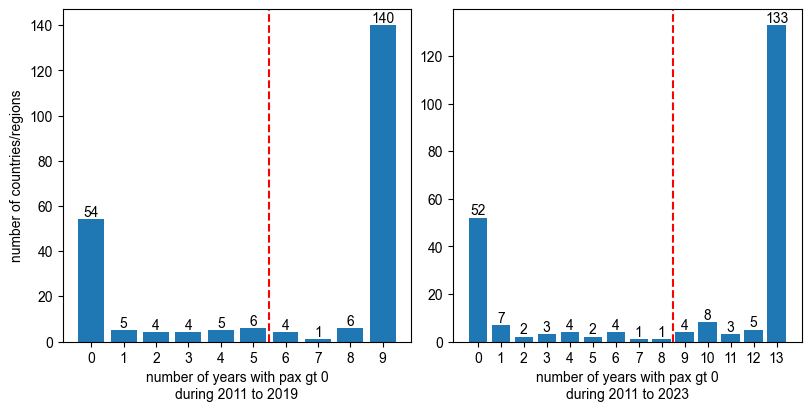

In [127]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")

ax = axs[0]
cc = (
    national_dom_traffic.loc[2011:2019]
    .apply(lambda x: np.sum(x != 0))
    .sort_values(ascending=False)
    .value_counts()
    .reindex(np.arange(10))
    .fillna(0)
)

bar_c = ax.bar(cc.index, cc.values)
ax.bar_label(bar_c)
ax.set(
    xticks=np.arange(10),
    ylabel="number of countries/regions",
    xlabel="number of years with pax gt 0\nduring 2011 to 2019",
)
ax.axvline(x=5.5, color="r", ls="--")

ax = axs[1]
cc = (
    national_dom_traffic.loc[2011:2023]
    .apply(lambda x: np.sum(x != 0))
    .sort_values(ascending=False)
    .value_counts()
    .reindex(np.arange(14))
    .fillna(0)
)

bar_c = ax.bar(cc.index, cc.values)
ax.bar_label(bar_c)
ax.set(
    xticks=np.arange(14), xlabel="number of years with pax gt 0\nduring 2011 to 2023"
)
ax.axvline(x=8.5, color="r", ls="--")

plt.show()

In [128]:
# country_iso = pd.DataFrame(
#     [[x.alpha_2, x.alpha_3, x.name] for x in pycountry.countries.objects],
#     columns=["ISO2", "ISO3", "name"],
# )
# sov_map = (
#     gpd.read_file("../data/RAW/ne_10m_admin_0_countries_iso.zip")
#     .set_index("ISO_A3_EH")["SOV_A3"]
#     .to_dict()
# )

# country_iso["SOV_A3"] = country_iso["ISO3"].map(sov_map)
# # country_iso['WHO_member'] = country_iso['ISO2'].map(lambda x: "T" if x in who_countries else "F")
# country_iso["OAG_pax"] = country_iso["ISO2"].map(
#     lambda x: "T" if x in countries_with_traffic else "F"
# )
# country_iso["Total_traffic"] = country_iso["ISO2"].map(
#     lambda x: "T" if x in countries else "F"
# )
# country_iso["International_traffic"] = country_iso["ISO2"].map(
#     lambda x: "T" if x in countries else "F"
# )
# country_iso["National_traffic"] = country_iso["ISO2"].map(
#     lambda x: "T" if x in countries_dom else "F"
# )

# country_iso.sort_values("SOV_A3").to_excel("./data/country_info.xlsx")

country_info = pd.read_excel("../data/country_info.xlsx", keep_default_na=False)
country_info

,ISO2,ISO3,name,SOV_A3,UN_member,WHO_member,OAG_pax,Total_traffic,International_traffic,National_traffic
0,AF,AFG,Afghanistan,AFG,T,T,T,T,T,T
1,AO,AGO,Angola,AGO,T,T,T,T,T,T
2,AL,ALB,Albania,ALB,T,T,T,T,T,F
3,AD,AND,Andorra,AND,T,T,F,F,F,F
4,AE,ARE,United Arab Emirates,ARE,T,T,T,T,T,T
...,...,...,...,...,...,...,...,...,...,...
244,WS,WSM,Samoa,WSM,T,T,T,T,T,F
245,YE,YEM,Yemen,YEM,T,T,T,T,T,T
246,ZA,ZAF,South Africa,ZAF,T,T,T,T,T,T
247,ZM,ZMB,Zambia,ZMB,T,T,T,T,T,T


## global level

In [129]:
all_traffic_yearly_ = all_traffic_yearly[
    (all_traffic_yearly["dep_country"].isin(countries))
    | (all_traffic_yearly["arr_country"].isin(countries))
]

In [130]:
global_traffic = (
    all_traffic_yearly_.groupby(["year", "type2"])["traffic"].sum().unstack(1)
)
global_traffic2 = (
    all_traffic_yearly_.groupby(["year", "type"])["traffic"].sum().unstack(1)
)

global_traffic["international"] = global_traffic2["international"]
global_traffic["total"] = global_traffic2.sum(axis=1)

global_traffic = global_traffic.reindex(
    columns=["total", "national", "international", "intra-region", "extra-region"]
)

global_traffic

type2,total,national,international,intra-region,extra-region
year,,,,,
2011,2331714594,1355634563,976080031,590986695,385093336
2012,2436158774,1411171164,1024987610,625110029,399877581
2013,2623579533,1503261231,1120318302,667587293,452731009
2014,2787578484,1601648478,1185930006,705414839,480515167
2015,2975043316,1707470866,1267572450,753626722,513945728
2016,3182238866,1811610347,1370628519,834920331,535708188
2017,3445109670,1970951841,1474157829,899742807,574415022
2018,3675540626,2109988613,1565552013,956057224,609494789
2019,3783775128,2170903754,1612871374,987160911,625710463


In [131]:
print(f"Total traffic in 2024: {global_traffic.loc[2024, 'total']:,.0f}")
print(
    f"Internatioanl traffic: {global_traffic.loc[2024, 'international']:,.0f} {global_traffic.loc[2024, 'international'] / global_traffic.loc[2024, 'total']:.2%}"
)
print(
    f"Domestic traffic     : {global_traffic.loc[2024, 'national']:,.0f} {global_traffic.loc[2024, 'national'] / global_traffic.loc[2024, 'total']:.2%}"
)


Total traffic in 2024: 3,902,075,930
Internatioanl traffic: 1,647,467,063 42.22%
Domestic traffic     : 2,254,608,867 57.78%


In [132]:
print(
    f"Total traffic change        : {global_traffic.loc[2019, 'total'] / global_traffic.loc[2011, 'total'] - 1:.2%}"
)
print(
    f"Internatioanl traffic change: {global_traffic.loc[2019, 'international'] / global_traffic.loc[2011, 'international'] - 1:.2%}"
)
print(
    f"Domestic traffic change.    : {global_traffic.loc[2019, 'national'] / global_traffic.loc[2011, 'national'] - 1:.2%}"
)

Total traffic change        : 62.27%
Internatioanl traffic change: 65.24%
Domestic traffic change.    : 60.14%


In [133]:
print(
    f"Total traffic reyovery        : {global_traffic.loc[2024, 'total'] / global_traffic.loc[2019, 'total']:.2%}"
)
print(
    f"Internatioanl traffic reyovery: {global_traffic.loc[2024, 'international'] / global_traffic.loc[2019, 'international']:.2%}"
)
print(
    f"Domestic traffic reyovery.    : {global_traffic.loc[2024, 'national'] / global_traffic.loc[2019, 'national']:.2%}"
)

Total traffic reyovery        : 103.13%
Internatioanl traffic reyovery: 102.14%
Domestic traffic reyovery.    : 103.86%


# Global landscape of air passenger travel

In [134]:
all_traffic_monthly_ = all_traffic_monthly

In [135]:
global_traffic_monthly = (
    all_traffic_monthly_.groupby(["time2", "type"])["traffic"].sum().unstack(1)
)
global_traffic_monthly["total"] = (
    global_traffic_monthly["national"] + global_traffic_monthly["international"]
)
global_traffic_monthly

type,international,national,total
time2,,,
2011-01-01,74259217,105576467,179835684
2011-02-01,66951803,98529679,165481482
2011-03-01,76600757,113221589,189822346
2011-04-01,80863681,111504449,192368130
2011-05-01,84615737,116965628,201581365
...,...,...,...
2024-08-01,158342649,204461801,362804450
2024-09-01,146029952,186314074,332344026
2024-10-01,145567641,195988795,341556436


In [136]:
npi = pd.read_csv("../data/RAW/owid-covid-data-old.csv")
npi_wide = pd.pivot_table(
    data=npi, values="stringency_index", index="date", columns="iso_code"
)

pop = (
    pd.pivot_table(data=npi, values="population", index="date", columns="iso_code")
    .reindex(columns=npi_wide.columns)
    .iloc[-1, :]
    .values
)
pop_std = pop / pop.sum()

npi_m = npi_wide.fillna(0).values
npi_average = (npi_m * pop_std).sum(axis=1)

npi_ts = pd.to_datetime(npi_wide.index)
low, md, high = np.percentile(npi_m, q=[25, 50, 75], axis=1)

## dispariteies (COV)

In [141]:
y_ = national_int_traffic.loc[2024, countries].values
np.sqrt(np.sum((y_ - y_.mean()) ** 2)) / y_.mean()

np.float64(29.36348695955048)

In [142]:
y_ = national_dom_traffic.loc[2024, countries].values
np.sqrt(np.sum((y_ - y_.mean()) ** 2)) / y_.mean()

np.float64(74.17117067083299)

### recovery

In [184]:
recovery_df = national_traffic.loc[2020:2024] / national_traffic.loc[2019]
recovery_int_df = national_int_traffic.loc[2020:2024] / national_int_traffic.loc[2019]
recovery_dom_df = national_dom_traffic.loc[2020:2024] / national_dom_traffic.loc[2019]

### population normalized

In [187]:
un_pop_w.head()

ISO2_code,AE,AF,AG,AL,AM,AO,AR,AT,AU,AZ,...,UZ,VC,VE,VN,VU,WS,YE,ZA,ZM,ZW
Time,,,,,,,,,,,,,,,,,,,,,
2011,7199.424,29347.708,86.332,2911.504,2923.270,24218.352,41730.660,8393.270,22479.775,9256.150,...,28823.196,109.348,29185.212,88468.314,243.474,194.713,27582.897,52995.205,14437.796,13595.424
2012,7497.118,30560.034,87.260,2910.004,2922.528,25177.394,42161.722,8431.601,22852.644,9376.180,...,29261.903,108.736,29553.826,89510.356,248.884,196.498,28433.647,53782.566,14913.629,13817.887
2013,7831.847,31622.704,88.064,2907.573,2922.518,26165.620,42582.455,8481.406,23236.270,9504.409,...,29724.065,108.135,29912.198,90573.104,254.482,198.268,29312.952,54678.792,15398.997,14013.808
2014,8236.874,32792.523,88.765,2903.750,2922.422,27160.769,43024.071,8547.818,23595.601,9631.138,...,30222.994,107.535,30254.079,91679.578,260.240,200.037,30226.309,55594.838,15895.315,14207.358
2015,8674.633,33831.764,89.409,2898.632,2921.177,28157.798,43477.012,8644.038,23948.002,9752.850,...,30749.346,106.960,30573.972,92823.254,266.101,201.782,31159.379,56723.537,16399.089,14399.013


$X_{ij}$ represent X * 1000 population in country j in year i

In [189]:
national_paxp = pd.DataFrame()

for year in range(2011, 2025):
    tmp = (
        all_traffic_yearly.query("year == @year")
        .groupby(["dep_country", "arr_country"])["traffic"]
        .sum()
        .unstack(1)
        .reindex(index=countries, columns=countries)
        .fillna(0)
    )
    tmp = tmp.divide(un_pop_w.loc[year, countries] * 1000, axis=0)

    national_dom_paxp = (
        pd.Series(index=countries, data=tmp.values.diagonal()).fillna(0).rename("paxp")
    )
    national_dom_paxp.index.name = "country"
    national_int_dep_paxp = tmp.sum(axis=1).rename("paxp") - national_dom_paxp
    national_int_dep_paxp.index.name = "country"
    national_int_arr_paxp = tmp.sum(axis=0).rename("paxp") - national_dom_paxp
    national_int_arr_paxp.index.name = "country"

    national_int_paxp = national_int_dep_paxp + national_int_arr_paxp

    tmp = pd.DataFrame(
        {
            "paxp_dom": national_dom_paxp,
            "paxp_int_dep": national_int_dep_paxp,
            "paxp_int_arr": national_int_arr_paxp,
            "paxp_int": national_int_paxp,
            "paxp_tot": national_dom_paxp + national_int_paxp,
        }
    ).reset_index()

    tmp["year"] = year

    national_paxp = pd.concat([national_paxp, tmp], ignore_index=True)

In [190]:
national_paxp_2024 = national_paxp.query("year == 2024")
national_paxp_2024

,country,paxp_dom,paxp_int_dep,paxp_int_arr,paxp_int,paxp_tot,year
2535,AE,0.000039,3.446326,2.946418,6.392744,6.392783,2024
2536,AF,0.009280,0.015877,0.033874,0.049751,0.059031,2024
2537,AG,0.000000,4.141673,0.772323,4.913996,4.913996,2024
2538,AL,0.000000,1.649402,0.162829,1.812231,1.812231,2024
2539,AM,0.000000,0.734317,0.159353,0.893671,0.893671,2024
...,...,...,...,...,...,...,...
2725,WS,0.000000,0.908302,0.109865,1.018167,1.018167,2024
2726,YE,0.001447,0.008282,0.027077,0.035359,0.036806,2024
2727,ZA,0.200310,0.083078,0.750504,0.833583,1.033893,2024
2728,ZM,0.013637,0.027544,0.035370,0.062914,0.076551,2024


In [194]:
global_int_avg = all_traffic_yearly.query(
    "type == 'international' and dep_country in @countries and arr_country in @countries"
).groupby("year")["traffic"].sum() / (un_pop_w.loc[:, countries].sum(axis=1) * 1000)

global_dom_avg = all_traffic_yearly.query(
    "type == 'national' and dep_country in @countries"
).groupby("year")["traffic"].sum() / (un_pop_w.loc[:, countries].sum(axis=1) * 1000)

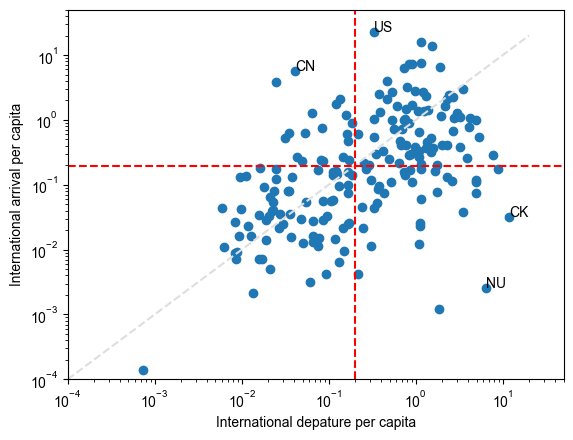

In [195]:
plt.plot([1e-4, 20], [1e-4, 20], ls="--", color="#DEDEDE")

global_int_avg_ = global_int_avg.loc[2024]
plt.axhline(y=global_int_avg_, ls="--", color="r")
plt.axvline(x=global_int_avg_, ls="--", color="r")

plt.scatter(x=national_int_dep_paxp, y=national_int_arr_paxp)


plt.xlabel("International depature per capita")
plt.ylabel("International arrival per capita")

plt.text(national_int_dep_paxp["US"], national_int_arr_paxp["US"], "US")
plt.text(national_int_dep_paxp["CK"], national_int_arr_paxp["CK"], "CK")
plt.text(national_int_dep_paxp["NU"], national_int_arr_paxp["NU"], "NU")
plt.text(national_int_dep_paxp["CN"], national_int_arr_paxp["CN"], "CN")
plt.xlim(1e-4, 50)
plt.ylim(1e-4, 50)

plt.loglog()

plt.show()

In [433]:
national_paxp.query("year < 2020").groupby("country").agg(np.median).head(50)

,paxp_dom,paxp_int_dep,paxp_int_arr,paxp_int,paxp_tot,year
country,,,,,,
AE,0.004215,3.159392,2.798625,5.873839,5.887278,2015.0
AF,0.017716,0.021057,0.038731,0.059788,0.076055,2015.0
AG,0.000000,3.983309,0.823643,4.849308,4.925589,2015.0
AL,0.000000,0.370156,0.042448,0.409403,0.409403,2015.0
AM,0.000000,0.369266,0.035159,0.407684,0.407727,2015.0
AO,0.031092,0.030460,0.122048,0.155474,0.197523,2015.0
AR,0.209690,0.136661,0.277994,0.408879,0.615207,2015.0
AT,0.020522,1.191817,0.914158,2.105975,2.128372,2015.0
AU,2.172896,0.731599,6.433700,7.261812,9.434708,2015.0


In [431]:
f"{0.004215:e}"

'4.215000e-03'

## vis

In [354]:
labels = [
    r"$<10^5$",
    r"$ \geq 10^5$ to < $5 \times 10^5$",
    r"$ \geq 5 \times 10^5$ to < $10^6$",
    r"$ \geq 10^6$ to < $5 \times 10^6$",
    r"$ \geq 5 \times 10^6$ to < $10^7$",
    r"$ \geq 10^6$ to < $5 \times 10^7$",
    r"$ \geq 5 \times 10^7$ to < $10^8$",
    r"$ \geq 10^7$ to < $5 \times 10^8$",
    r"$ \geq 5 \times 10^8$ to < $10^9$",
]
bins = [0, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8]

our_cmap = mpl.colormaps["RdYlBu_r"]
newcolors = our_cmap(np.linspace(0, 1, len(bins)))[1:]
our_cmap = ListedColormap(newcolors)

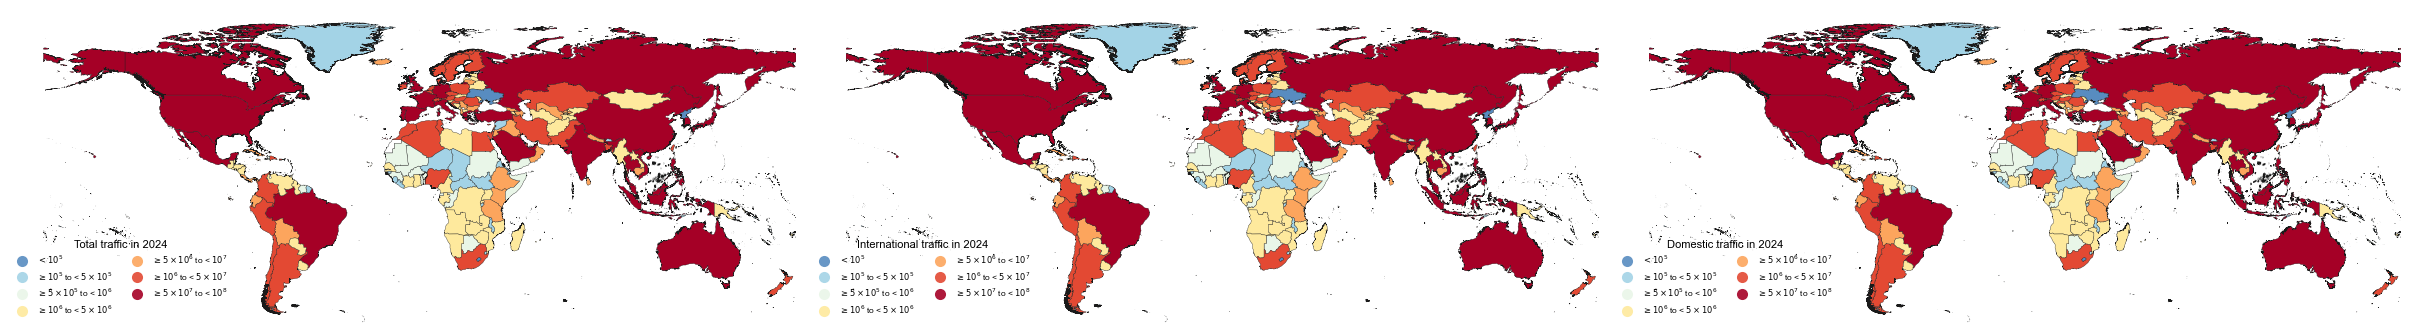

In [355]:
fig = plt.figure(figsize=(24, 8), layout='constrained')

bar_labels = [
    "Total traffic in 2024",
    "International traffic in 2024",
    "Domestic traffic in 2024",
]

for i, df in enumerate([national_traffic, national_int_traffic, national_dom_traffic]):
    ax = plt.subplot(1, 3, i + 1, projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
    
    adm0_ = adm0.assign(value=adm0['alpha2'].map(national_traffic.loc[2024, :].to_dict()))
    ax.add_geometries(
        adm0_.geometry, 
        array=adm0_['value'],
        cmap=our_cmap,
        norm=mcolors.BoundaryNorm(bins, ncolors=len(bins) - 1),
        linewidth=0.25,
        edgecolor='.1',
        crs=ccrs.PlateCarree(),
    )
    ax.add_geometries(cn_south.geometry, lw=1, ec='.1', fc='none', crs=ccrs.PlateCarree())

    handles = []
    for k, v in zip(labels, newcolors):
        handles.append(
            Line2D(
                [0],
                [0],
                lw=0,
                marker="o",
                markeredgecolor="none",
                markersize=8,
                markerfacecolor=v,
                label=k,
                alpha=0.9,
            )
        )
    ax.legend(
        loc="lower left",
        bbox_to_anchor=[-0.05, 0],
        handles=handles,
        frameon=False,
        fontsize=6,
        ncols=2,
        title=bar_labels[i],
        title_fontsize=8,
    )
    ax.set_axis_off()

plt.show()

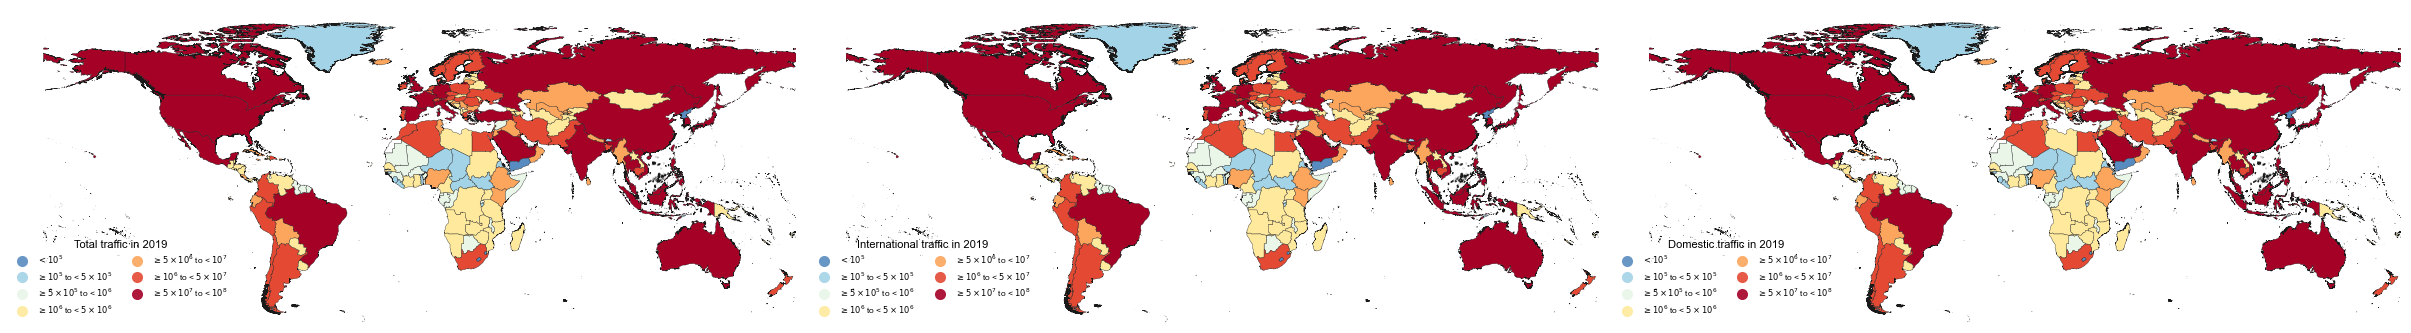

In [356]:
fig = plt.figure(figsize=(24, 8), layout='constrained')

bar_labels = [
    "Total traffic in 2019",
    "International traffic in 2019",
    "Domestic traffic in 2019",
]

for i, df in enumerate([national_traffic, national_int_traffic, national_dom_traffic]):
    ax = plt.subplot(1, 3, i + 1, projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
    
    adm0_ = adm0.assign(value=adm0['alpha2'].map(national_traffic.loc[2019, :].to_dict()))
    ax.add_geometries(
        adm0_.geometry, 
        array=adm0_['value'],
        cmap=our_cmap,
        norm=mcolors.BoundaryNorm(bins, ncolors=len(bins) - 1),
        linewidth=0.25,
        edgecolor='.1',
        crs=ccrs.PlateCarree(),
    )
    ax.add_geometries(cn_south.geometry, lw=1, ec='.1', fc='none', crs=ccrs.PlateCarree())

    handles = []
    for k, v in zip(labels, newcolors):
        handles.append(
            Line2D(
                [0],
                [0],
                lw=0,
                marker="o",
                markeredgecolor="none",
                markersize=8,
                markerfacecolor=v,
                label=k,
                alpha=0.9,
            )
        )
    ax.legend(
        loc="lower left",
        bbox_to_anchor=[-0.05, 0],
        handles=handles,
        frameon=False,
        fontsize=6,
        ncols=2,
        title=bar_labels[i],
        title_fontsize=8,
    )
    ax.set_axis_off()

plt.show()

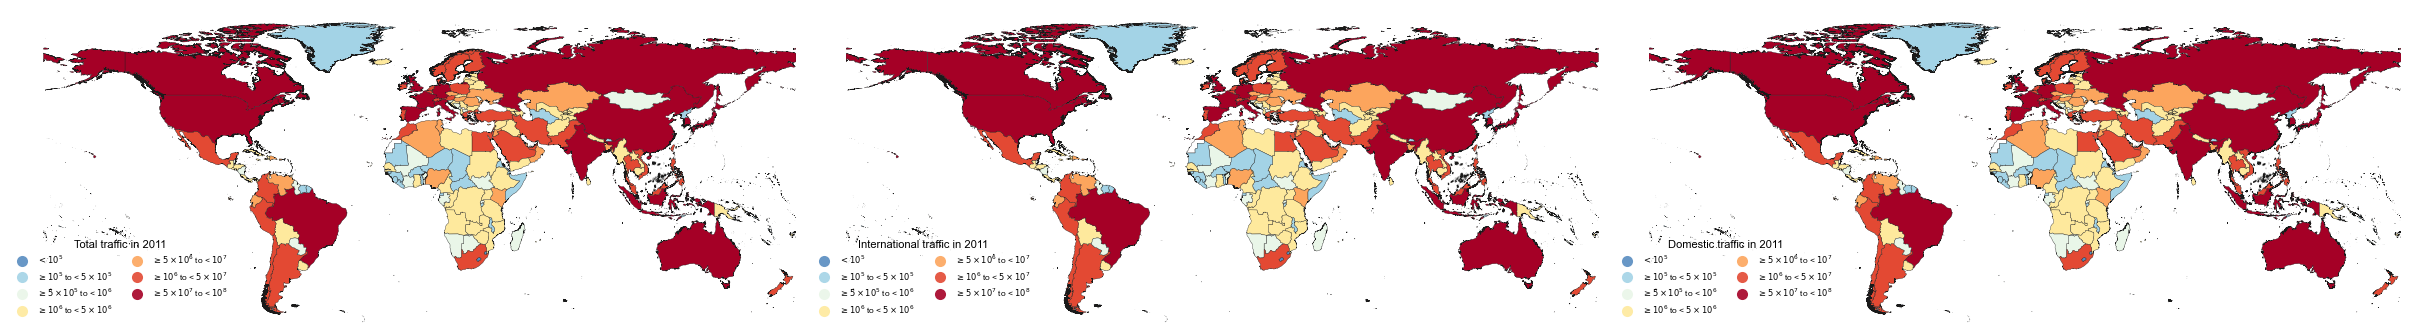

In [357]:
fig = plt.figure(figsize=(24, 8), layout='constrained')

bar_labels = [
    "Total traffic in 2011",
    "International traffic in 2011",
    "Domestic traffic in 2011",
]

for i, df in enumerate([national_traffic, national_int_traffic, national_dom_traffic]):
    ax = plt.subplot(1, 3, i + 1, projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
    
    adm0_ = adm0.assign(value=adm0['alpha2'].map(national_traffic.loc[2011, :].to_dict()))
    ax.add_geometries(
        adm0_.geometry, 
        array=adm0_['value'],
        cmap=our_cmap,
        norm=mcolors.BoundaryNorm(bins, ncolors=len(bins) - 1),
        linewidth=0.25,
        edgecolor='.1',
        crs=ccrs.PlateCarree(),
    )
    ax.add_geometries(cn_south.geometry, lw=1, ec='.1', fc='none', crs=ccrs.PlateCarree())

    handles = []
    for k, v in zip(labels, newcolors):
        handles.append(
            Line2D(
                [0],
                [0],
                lw=0,
                marker="o",
                markeredgecolor="none",
                markersize=8,
                markerfacecolor=v,
                label=k,
                alpha=0.9,
            )
        )
    ax.legend(
        loc="lower left",
        bbox_to_anchor=[-0.05, 0],
        handles=handles,
        frameon=False,
        fontsize=6,
        ncols=2,
        title=bar_labels[i],
        title_fontsize=8,
    )
    ax.set_axis_off()

plt.show()

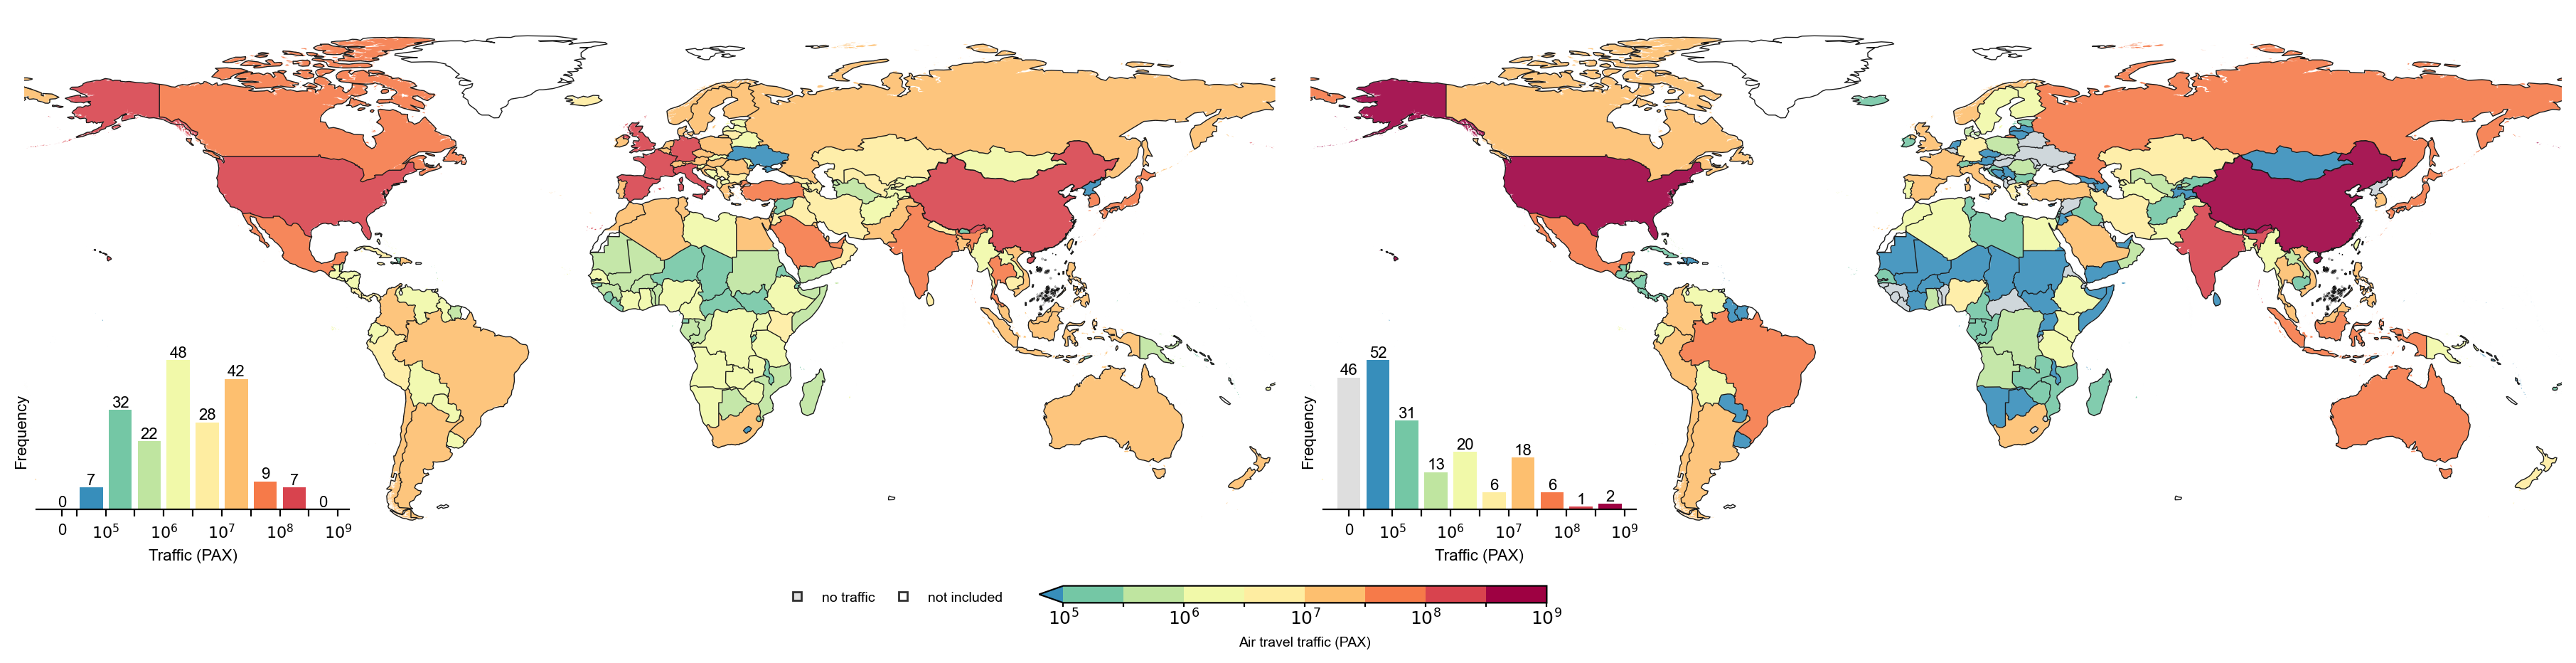

In [360]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=200
)
axs = np.ravel(axs)

bins = [1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8, 5e8, 1e9]
labels = [r"$10^5$", r"", r"$10^6$", r"", r"$10^7$", r"", r"$10^8$", r"", r"$10^9$"]

cmap = ListedColormap(
    mpl.colormaps["Spectral_r"](np.linspace(0, 1, len(bins)+1))[1:] # remove lowest color
)
norm = mcolors.BoundaryNorm(boundaries=bins, ncolors=len(bins)+1, extend='min')

for i, (df, cc, label) in enumerate(
    zip(
        [national_int_traffic, national_dom_traffic],
        [countries, countries],
        ["International", "Domestic"],
    )
):
    ax = axs[i]
    ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())

    adm0_ = adm0.assign(value=lambda x: x["alpha2"].map(df.loc[2024, cc].to_dict()))
    art = ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["value"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    ax.add_geometries(
        adm0_.query("value==0")["geometry"].values,
        crs=ccrs.PlateCarree(),
        facecolor="#DEDEDE",
        edgecolor="none",
        alpha=0.9,
        rasterized=True,
    )
    
    ax.add_geometries(cn_south.geometry, lw=1, ec='.1', fc='none', crs=ccrs.PlateCarree())
    
    draw_maps(get_adm_maps(country='中国', level='国'), color='.1', lw=.3, ax=ax)
    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.5)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.5)
    ax.set_axis_off()

    ax_ = ax.inset_axes([0.01, 0.05, 0.25, 0.3])

    ct = (
        pd.cut(df.loc[2024, cc], bins=[0, 1] + bins, ordered=True, right=False)
        .value_counts(sort=False)
        .values
    )
    bars = ax_.bar(np.arange(len(ct)), ct)
    ax_.bar_label(bars, ct, fontsize=8)
    for i, bar in enumerate(bars):
        bar.set_fc(cmap(i / len(ct)))
        if i == 0:
            bar.set_fc("#DEDEDE")

    ax_.set_yticks([])
    ax_.set_xticks(np.hstack([0, np.arange(0, (len(bins) + 1)) + 0.5]), ["0", ""] + labels)
    ax_.tick_params(axis="both", labelsize=8)
    ax_.set_xlabel("Traffic (PAX)", fontsize=8)
    ax_.set_ylabel("Frequency", fontsize=8)
    ax_.spines[["top", "left", "right"]].set_visible(False)

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    ax=axs,
    orientation="horizontal",
    shrink=0.20,
    pad=0.02,
    aspect=30,
)
cbar.set_ticks(bins, labels=labels, fontsize=9)
cbar.set_label("Air travel traffic (PAX)", fontsize=7)
cbar.ax.tick_params("both", size=2, pad=1)

handles = [
    Line2D([0], [0], lw=0, marker="s", mec=".1", ms=4, mfc="#DEDEDE", label="no traffic", alpha=0.9,),
    Line2D([0], [0], lw=0, marker="s", mec=".1", ms=4, mfc="#FFFFFF", label="not included", alpha=0.9,),
]
cbar.ax.legend(
    loc="center right",
    bbox_to_anchor=[-0.1, 0.3],
    handles=handles,
    frameon=False,
    fontsize=7,
    ncols=2,
    columnspacing=1,
)

plt.show()

## Figure 2

Traffic International 195
Traffic Domestic 195
Traffic per capita International 195
Traffic per capita Domestic 195
Recovery International 195
Recovery Domestic 155


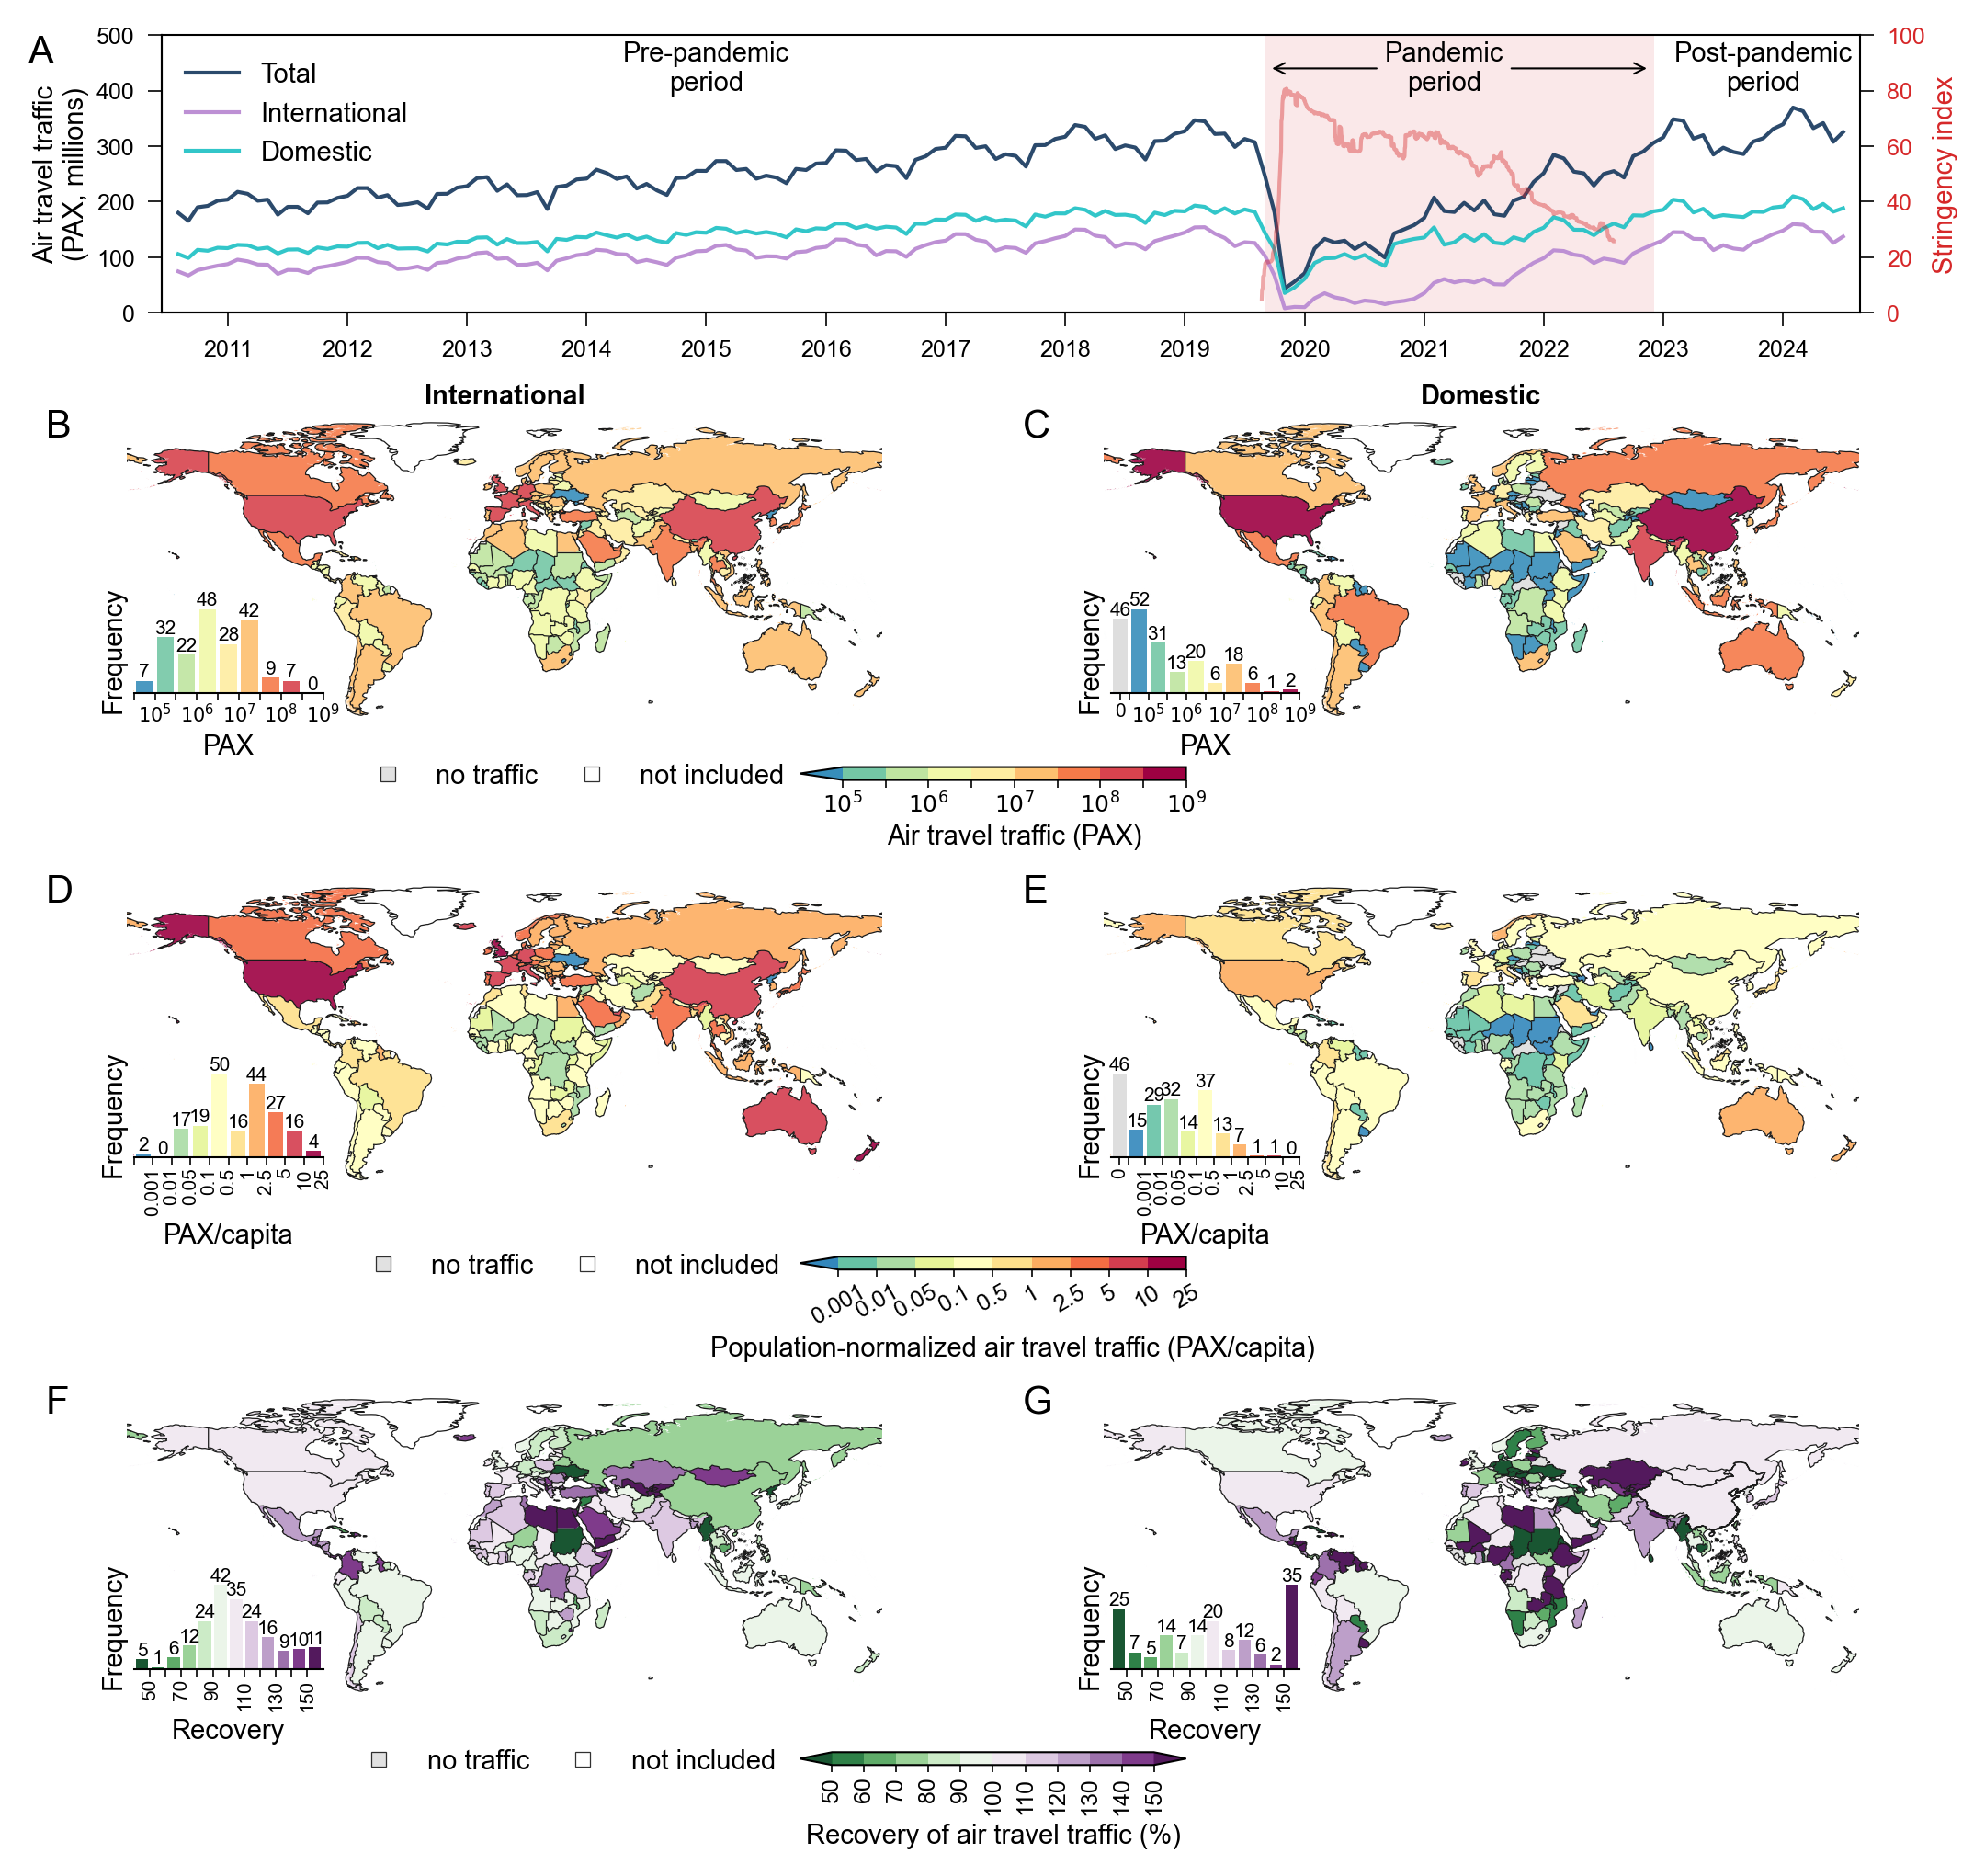

In [365]:
cm = 1 / 2.54  # centimeters in inches

style = {
    "lines.linewidth": 0.5,
    "lines.markeredgewidth": 0.3,
    "font.size": 7.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 6,
    "axes.labelpad": 2,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
    "xtick.major.width": 0.4,
    "ytick.major.width": 0.4,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.titlepad": 0,
}

cbar_shrink = 0.3
cbar_pad = -0.1

index_axes = [0.01, 0.1, 0.25, 0.28]

with mpl.rc_context(style):
    fig = plt.figure(layout="constrained", figsize=(18 * cm, 17 * cm), dpi=300)
    top, bottom = fig.subfigures(
        nrows=2, ncols=1, height_ratios=(0.725, 3.025), hspace=0.0, wspace=0.0
    )


    # *****************************************
    ax = top.add_subplot(111)
    ax.text(
        0.0,
        1.0,
        "A",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-35 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="top",
    )

    ax.plot(
        global_traffic_monthly.index.values,
        global_traffic_monthly["total"].values,
        lw=1,
        color="#14365C",
        alpha=0.9,
        label="Total",
    )
    ax.plot(
        global_traffic_monthly.index.values,
        global_traffic_monthly["international"].values,
        lw=1,
        color="#BD90D4",
        alpha=1.0,
        label="International",
    )
    ax.plot(
        global_traffic_monthly.index.values,
        global_traffic_monthly["national"].values,
        lw=1,
        color="#1BC0C4",
        alpha=0.9,
        label="Domestic",
    )

    ax.text(
        pd.to_datetime("2015-6-1"),
        440_000_000,
        f"Pre-pandemic\nperiod",
        ha="center",
        va="center",
        fontsize=7,
    )
    ax.text(
        pd.to_datetime("2021-8-1"),
        440_000_000,
        f"Pandemic\nperiod",
        ha="center",
        va="center",
        fontsize=7,
    )
    ax.text(
        pd.to_datetime("2024-4-1"),
        440_000_000,
        f"Post-pandemic\nperiod",
        ha="center",
        va="center",
        fontsize=7,
    )

    ax.axvspan(
        xmin=pd.to_datetime("2020-01-30"),
        xmax=pd.to_datetime("2023-05-05"),
        color="C3",
        alpha=0.1,
        lw=0,
    )

    ax.annotate(
        "",
        xy=(pd.to_datetime("2020-01-30"), 440_000_000),
        xytext=(pd.to_datetime("2021-01-30"), 440_000_000),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3", lw=0.5),
    )
    ax.annotate(
        "",
        xy=(pd.to_datetime("2023-05-05"), 440_000_000),
        xytext=(pd.to_datetime("2022-01-30"), 440_000_000),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3", lw=0.5),
    )

    ax.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0, 0.99),
        fontsize=7,
        ncols=1,
        handlelength=2,
    )

    ax.xaxis.set_major_locator(mdates.MonthLocator(6))
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x * 1e-6:1.0f}")
    ax.set_ylim(0, 500_000_000)
    ax.set_ylabel(
        "Air travel traffic\n(PAX, millions)", fontdict={"family": "Arial", "size": 7}
    )
    ax.tick_params(labelsize=6)

    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xmargin(0.01)

    ax_ = ax.twinx()
    ax_.plot(npi_ts, npi_average, color="C3", alpha=0.4, lw=1)
    ax_.set_ylim(0, 100)
    ax_.set_ylabel(
        "Stringency index", color="C3", fontdict={"family": "Arial", "size": 7}
    )
    ax_.tick_params(axis="y", labelcolor="C3", labelsize=6)
    ax_.set_xmargin(0.01)


    # #*****************************************
    axs = bottom.subplot_mosaic(
        "BC;DE;FG",
        subplot_kw={"projection": ccrs.PlateCarree()},
        height_ratios=(1, 1, 1),
        gridspec_kw={"wspace": 0, "hspace": 0},
    )

    for i, (la, df, cc, label) in enumerate(
        zip(
            ["B", "C"],
            [national_int_traffic, national_dom_traffic],
            [countries, countries],
            ["International", "Domestic"],
        )
    ):
        bins = [1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8, 5e8, 1e9]
        labels = [ r"$10^5$", r"", r"$10^6$", r"", r"$10^7$", r"", r"$10^8$", r"", r"$10^9$"]
        
        cmap = ListedColormap(
            mpl.colormaps["Spectral_r"](np.linspace(0, 1, len(bins)+1))[1:]
        )
        norm = mcolors.BoundaryNorm(boundaries=bins, ncolors=len(bins)+1, extend='min')

        ax = axs[la]
        ax.text(
            0.0,
            1.0,
            la.upper(),
            fontsize=10,
            transform=(
                ax.transAxes + ScaledTranslation(-21 / 72, 0 / 72, fig.dpi_scale_trans)
            ),
            va="top",
        )

        ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
        ax.set_axis_off()

        adm0_ = adm0.assign(var1=adm0["alpha2"].map((df.loc[2024, cc]).to_dict()))
        ax.add_geometries(
            adm0_.query("var1>0")["geometry"].values,
            crs=ccrs.PlateCarree(),
            array=adm0_.query("var1>0")["var1"].values,
            cmap=cmap,
            norm=norm,
            alpha=0.9,
            rasterized=True,
        )

        ax.add_geometries(
            adm0_.query("var1==0")["geometry"].values,
            crs=ccrs.PlateCarree(),
            facecolor="#DEDEDE",
            edgecolor="none",
            alpha=0.9,
            rasterized=True,
        )

        ax.add_geometries(cn_south.geometry, lw=.5, ec='.1', fc='none', crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
        ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
        ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)


        ax_ = ax.inset_axes(index_axes)
        ct = (
            pd.cut(df.loc[2024, cc], bins=[0, 1]+bins, ordered=True, right=False)
            .value_counts(sort=False)
            .values
        )
        if ct[0] == 0:
            bars = ax_.bar(np.arange(len(ct)-1), ct[1:])
            ax_.bar_label(bars, ct[1:], fontsize=5)
            for i, bar in enumerate(bars):
                bar.set(fc=cmap((i+1) / len(ct)), ec='none', alpha=.9)
            
            ax_.set_xticks(np.arange(len(bars)+1)-0.5, [''] + labels, fontsize=5, fontfamily="Arial")
            
        else:
            bars = ax_.bar(np.arange(len(ct)), ct)
            ax_.bar_label(bars, ct, fontsize=5)
            for i, bar in enumerate(bars):
                if i == 0:
                    bar.set(fc="#DEDEDE", ec="none")
                    continue
                bar.set(fc=cmap(i / len(ct)), ec='none', alpha=.9)
            
            ax_.set_xticks(np.hstack([0, np.arange(0, len(bars)) + 0.5]), ['0', ''] + labels, fontsize=5, fontfamily="Arial")
            

        print(f"Traffic {label} {ct.sum()}")

        ax_.tick_params(axis="both", size=2, pad=0.5)
        ax_.set_yticks([])
        ax_.set_xlabel("PAX", fontsize=7)
        ax_.set_ylabel("Frequency", fontsize=7)
        ax_.spines[["top", "left", "right"]].set_visible(False)

        ax.set_title(label, fontsize=7, fontweight="bold")

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
        ax=[axs["B"], axs["C"]],
        orientation="horizontal",
        shrink=0.20,
        pad=-0.02,
        aspect=30,
        extendfrac='auto'
    )
    cbar.set_ticks(bins, labels=labels, fontsize=6)
    cbar.set_label(f"Air travel traffic (PAX)", fontsize=7)
    cbar.ax.tick_params("both", size=2, pad=1)

    handles = [
        Line2D(
            [0],
            [0],
            lw=0,
            marker="s",
            markeredgecolor=".1",
            markersize=4,
            markerfacecolor="#DEDEDE",
            label="no traffic",
            alpha=0.9,
        ),
        Line2D(
            [0],
            [0],
            lw=0,
            marker="s",
            markeredgecolor=".1",
            markersize=4,
            markerfacecolor="#FFFFFF",
            label="not included",
            alpha=0.9,
        ),
    ]
    cbar.ax.legend(
        loc="center right",
        bbox_to_anchor=[-0.1, 0.3],
        handles=handles,
        frameon=False,
        fontsize=7,
        ncols=2,
        columnspacing=1,
    )

    for i, (la, df, cc, label) in enumerate(
        zip(
            ["D", "E"],
            [national_int_dep_paxp + national_int_arr_paxp, national_dom_paxp],
            [countries, countries],
            ["International", "Domestic"],
        )
    ):
        bar_labels = ["International traffic in 2011", "Domestic traffic in 2011"]

        bins = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2.5, 5, 10, 25]
        labels = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2.5, 5, 10, 25]
        cmap = ListedColormap(
            mpl.colormaps["Spectral_r"](np.linspace(0, 1, len(bins)+1))[1:]
        )
        norm = mcolors.BoundaryNorm(boundaries=bins, ncolors=len(bins)+1, extend='min')
        
        ax = axs[la]
        ax.text(
            0.0,
            1.0,
            la.upper(),
            fontsize=10,
            transform=(
                ax.transAxes + ScaledTranslation(-21 / 72, 0 / 72, fig.dpi_scale_trans)
            ),
            va="top",
        )

        ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
        ax.set_axis_off()

        adm0_ = adm0.assign(var1=lambda x: x["alpha2"].map(df.loc[cc].to_dict()))
        ax.add_geometries(
            adm0_.query("var1>0")["geometry"].values,
            crs=ccrs.PlateCarree(),
            array=adm0_.query("var1>0")["var1"].values,
            cmap=cmap,
            norm=norm,
            alpha=0.9,
            rasterized=True,
        )
        ax.add_geometries(
            adm0_.query("var1==0")["geometry"].values,
            crs=ccrs.PlateCarree(),
            facecolor="#DEDEDE",
            edgecolor="none",
            alpha=0.9,
            rasterized=True,
        )
        
        ax.add_geometries(cn_south.geometry, lw=.5, ec='.1', fc='none', crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
        ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
        ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

        ax_ = ax.inset_axes(index_axes)
        ct = pd.cut(df.loc[cc], bins=[0, 1e-9] + bins, ordered=True, right=False).value_counts(
            sort=False
        )

        print(f"Traffic per capita {label} {ct.sum()}")
        
        if ct[0] == 0:
            bars = ax_.bar(np.arange(len(ct)-1), ct[1:])
            ax_.bar_label(bars, ct[1:], fontsize=5)
            for i, bar in enumerate(bars):
                bar.set(fc=cmap((i+1) / len(ct)), ec='none', alpha=.9)
            
            ax_.set_xticks(np.arange(len(bars)+1)-0.5, [''] + labels, fontsize=5, rotation=90, fontfamily="Arial")
            
        else:
            bars = ax_.bar(np.arange(len(ct)), ct)
            ax_.bar_label(bars, ct, fontsize=5)
            for i, bar in enumerate(bars):
                if i == 0:
                    bar.set(fc="#DEDEDE", ec="none")
                    continue
                bar.set(fc=cmap(i / len(ct)), ec='none', alpha=.9)
            
            ax_.set_xticks(np.hstack([0, np.arange(0, len(bars)) + 0.5]), ['0', ''] + labels, fontsize=5, rotation=90, fontfamily="Arial")
            
        ax_.tick_params(axis="both", size=2, pad=0.5)
        ax_.set_yticks([])
        ax_.set_xlabel("PAX/capita", fontsize=7)
        ax_.set_ylabel("Frequency", fontsize=7)
        ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
        ax=[axs["D"], axs["E"]],
        orientation="horizontal",
        shrink=0.20,
        pad=-0.02,
        aspect=30,
        extendfrac='auto'
    )
    cbar.set_ticks(bins, labels=labels, fontsize=6, rotation=30)
    cbar.set_label(f"Population-normalized air travel traffic (PAX/capita)", fontsize=7)
    cbar.ax.tick_params("both", size=2, pad=1)

    handles = [
        Line2D(
            [0],
            [0],
            lw=0,
            marker="s",
            markeredgecolor=".1",
            markersize=4,
            markerfacecolor="#DEDEDE",
            label="no traffic",
            alpha=0.9,
        ),
        Line2D(
            [0],
            [0],
            lw=0,
            marker="s",
            markeredgecolor=".1",
            markersize=4,
            markerfacecolor="#FFFFFF",
            label="not included",
            alpha=0.9,
        ),
    ]
    cbar.ax.legend(
        loc="center right",
        bbox_to_anchor=[-0.1, 0.3],
        handles=handles,
        frameon=False,
        fontsize=7,
        ncols=2,
        columnspacing=1,
    )

    for i, (la, df, cc, label) in enumerate(
        zip(
            ["F", "G"],
            [national_int_traffic, national_dom_traffic],
            [countries, countries],
            ["International", "Domestic"],
        )
    ):
        trip_change_pct = df.loc[2024, cc] * 100 / df.loc[2019, cc]

        bins = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
        labels = [50, "", 70, "", 90, "", 110, "", 130, "", 150]
        cmap = ListedColormap(
            mpl.colormaps["PRGn_r"](np.linspace(0, 1, len(bins) + 1))#[1:]
        )
        norm = mcolors.BoundaryNorm(bins, ncolors=len(bins)+1, extend="both")

        ax = axs[la]
        ax.text(
            0.0,
            1.0,
            la.upper(),
            fontsize=10,
            transform=(
                ax.transAxes + ScaledTranslation(-21 / 72, 0 / 72, fig.dpi_scale_trans)
            ),
            va="top",
        )

        ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
        ax.set_axis_off()

        adm0_ = adm0.query("alpha2 in @cc").assign(
            var1=lambda x: x["alpha2"].map(trip_change_pct.to_dict())
        )
        ax.add_geometries(
            adm0_["geometry"].values,
            crs=ccrs.PlateCarree(),
            array=adm0_["var1"].values,
            cmap=cmap,
            norm=norm,
            alpha=0.9,
            rasterized=True,
        )
        ax.add_geometries(
            adm0_.loc[adm0_["var1"].map(np.isinf), "geometry"].values,
            crs=ccrs.PlateCarree(),
            facecolor=cmap(1.0),
            edgecolor="none",
            alpha=0.9,
            rasterized=True,
        )
        ax.add_geometries(
            adm0_.loc[adm0_["var1"].map(np.isnan), "geometry"].values,
            crs=ccrs.PlateCarree(),
            facecolor="#DEDEDE",
            edgecolor="none",
            alpha=0.9,
            rasterized=True,
        )
        
        ax.add_geometries(cn_south.geometry, lw=.5, ec='.1', fc='none', crs=ccrs.PlateCarree())
        
        ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
        ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
        ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)
        

        draw_maps(get_adm_maps(country='中国', level='国'), color='.1', lw=0.3)

        ax_ = ax.inset_axes(index_axes)
        ct = pd.cut(
            adm0_["var1"].dropna(),
            bins=[0] + bins + [np.inf],
            ordered=True,
            right=True,
            include_lowest=True,
        ).value_counts(sort=False)
        bars = ax_.bar(np.arange(len(ct)), ct)
        ax_.bar_label(bars, ct, fontsize=5)
        for i, bar in enumerate(bars):
            bar.set(fc=cmap((i) / len(ct)), ec="none", alpha=0.9)

        print(f"Recovery {label} {ct.sum()}")

        ax_.tick_params(axis="both", size=2, pad=0.5)
        ax_.set_xticks(np.arange(len(ct)-1) + 0.5, fontsize=5, labels=labels, rotation=90)
        ax_.set_yticks([])
        ax_.set_xlabel("Recovery", fontsize=7)
        ax_.set_ylabel("Frequency", fontsize=7)
        ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
        alpha=0.9,
        ax=[axs["F"], axs["G"]],
        orientation="horizontal",
        shrink=0.20,
        pad=-0.02,
        aspect=30,
        extendfrac='auto'
    )
    cbar.set_ticks(bins, labels=bins, fontsize=6, rotation=90)
    cbar.set_label("Recovery of air travel traffic (%)", fontsize=7)
    cbar.ax.tick_params("both", size=2, pad=1)

    handles = [
        Line2D(
            [0],
            [0],
            lw=0,
            marker="s",
            markeredgecolor=".1",
            markersize=4,
            markerfacecolor="#DEDEDE",
            label="no traffic",
            alpha=0.9,
        ),
        Line2D(
            [0],
            [0],
            lw=0,
            marker="s",
            markeredgecolor=".1",
            markersize=4,
            markerfacecolor="#FFFFFF",
            label="not included",
            alpha=0.9,
        ),
    ]
    cbar.ax.legend(
        loc="center right",
        bbox_to_anchor=[-0.1, 0.3],
        handles=handles,
        frameon=False,
        fontsize=7,
        ncols=2,
        columnspacing=1,
    )

    # plot_children(fig)

    plt.savefig("/root/zengjf/project/airTraffic/airTrend/results/fig/Fig2.pdf")
    plt.show()


In [205]:
national_traffic_net.query("year==2024 and dep_country != arr_country").sort_values("traffic", ascending=True).tail(10)

,year,dep_country,arr_country,traffic,dep_region,arr_region,type,type2
491236,2024,JP,KR,11400480,Asia-Pacific,Asia-Pacific,international,intra-region
492362,2024,KR,JP,11672853,Asia-Pacific,Asia-Pacific,international,intra-region
482384,2024,DE,ES,12087384,Europe,Europe,international,intra-region
484195,2024,ES,DE,12098583,Europe,Europe,international,intra-region
508815,2024,US,CA,13825326,Northern America,Northern America,international,intra-region
479380,2024,CA,US,13847144,Northern America,Northern America,international,intra-region
497783,2024,MX,US,18619118,Latin America and the Caribbean,Northern America,international,extra-region
508923,2024,US,MX,18928182,Northern America,Latin America and the Caribbean,international,extra-region
484214,2024,ES,GB,19279023,Europe,Europe,international,intra-region
485663,2024,GB,ES,19431389,Europe,Europe,international,intra-region


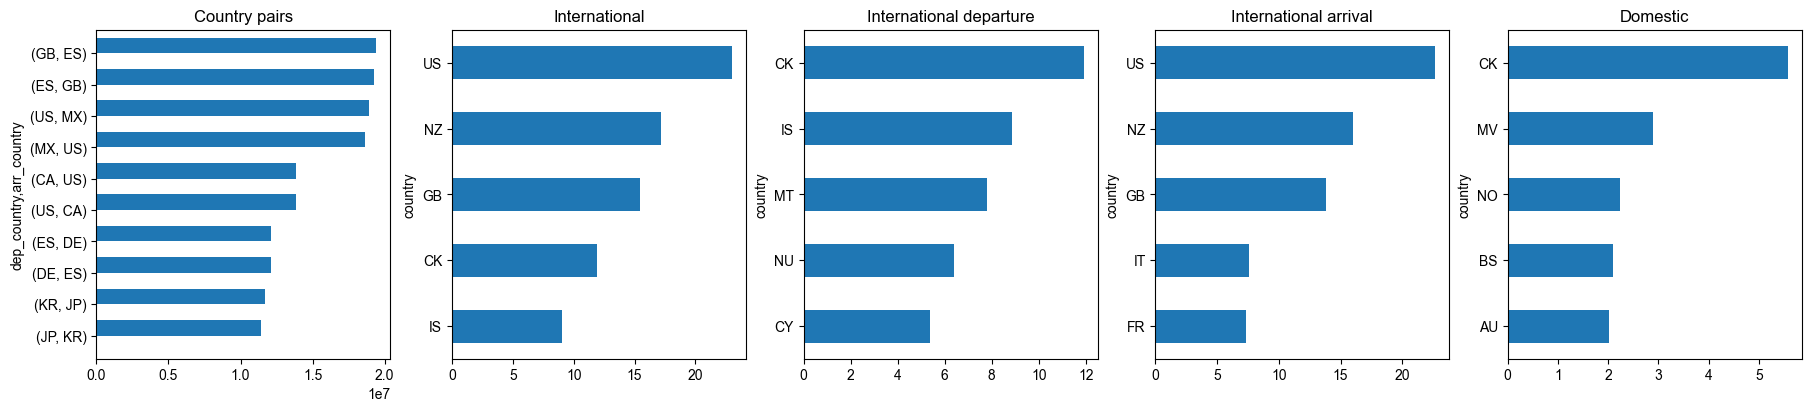

In [211]:
fig, axs = plt.subplots(1, 5, figsize=(18, 4), layout="constrained")

national_traffic_net.query("year==2024 and dep_country != arr_country").sort_values("traffic", ascending=True).tail(10).set_index(
    ["dep_country", "arr_country"]
).plot.barh(ax=axs[0], title="Country pairs", legend=False, color='C0', width=1.0)

national_int_paxp.sort_values(ascending=True).tail(5).plot.barh(
    ax=axs[1], title="International"
)
national_int_dep_paxp.sort_values(ascending=True).tail(5).plot.barh(
    ax=axs[2], title="International departure"
)
national_int_arr_paxp.sort_values(ascending=True).tail(5).plot.barh(
    ax=axs[3], title="International arrival"
)
national_dom_paxp.sort_values(ascending=True).tail(5).plot.barh(
    ax=axs[4], title="Domestic"
)

plt.show()

# Recovery

In [392]:
recovery_tmp = pd.DataFrame(
    {
        "recovery_int": recovery_int_df.loc[2024, countries].clip(0, 2),
        "recovery_dom": recovery_dom_df.loc[2024, countries].clip(0, 2),
    }
)
recovery_tmp["name"] = recovery_tmp.index.map(alpha2_to_country)
recovery_tmp["region"] = recovery_tmp.index.map(country2region)
recovery_tmp["region2"] = recovery_tmp.index.map(country2region2)
recovery_tmp.head()

,recovery_int,recovery_dom,name,region,region2
dep_country,,,,,
AE,1.270778,0.053523,United Arab Emirates,Western Asia,Western Asia
AF,0.851346,0.642686,Afghanistan,Southern Asia,Central and Southern Asia
AG,1.024230,NaN,Antigua and Barbuda,Latin America and the Caribbean,Latin America and the Caribbean
AL,2.000000,NaN,Albania,Southern Europe,Europe
AM,1.393229,NaN,Armenia,Western Asia,Western Asia


In [393]:
def currency(x, pos):
    """The two arguments are the value and tick position"""
    # if x >= 1e6:
    #     s = f'${x*1e-6:1.1f}M'
    # else:
    #     s = f'${x*1e-3:1.0f}K'
        
    return f"{x*100:.0f}"

UA 7.931683064836868e-06 0.0
SD 0.33674058407133156 0.007138466534451365
HT 0.3665632791167043 2.0
KP 0.40318646057919083 nan
MM 0.4392513358930116 0.4842382761597317
SY 0.5950235246707118 0.0
VU 0.603737983775864 0.2796297300361299
KH 0.6151439511040437 0.26884217483602474
MW 0.6311427023051465 0.4492564470683977
IL 0.6536894940624618 0.9361675723112108
AL 2.0 nan
YE 2.0 2.0
SZ 2.0 nan
LY 1.9154412444740396 2.0
UZ 1.9119061277098257 1.4711632702417168
SV 1.7852340083449112 nan
KG 1.618393116031088 1.8929014995706954
AZ 1.6036589538921675 6.711859856366199e-05
TJ 1.5907796583081784 2.0
EG 1.5072411509632524 1.2629302729562664


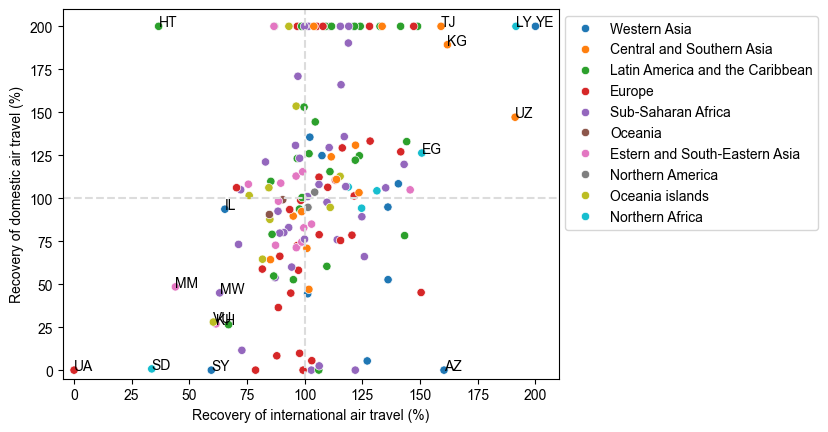

In [404]:
g = sns.scatterplot(data=recovery_tmp, x="recovery_int", y="recovery_dom", hue="region2")
g.set_ylim(-0.05, 2.1)
g.set_xlim(-0.05, 2.1)

g.axvline(x=1, ls="--", color="#DCDCDC")
g.axhline(y=1, ls="--", color="#DCDCDC")

g.set_xlabel("Recovery of international air travel (%)")
g.set_ylabel("Recovery of domestic air travel (%)")

g.xaxis.set_major_formatter(currency)
g.yaxis.set_major_formatter(currency)

labeled = []
texts = []
for i, row in recovery_tmp.sort_values('recovery_int').head(10).iterrows():
    if i in labeled:
        continue
    
    print(i, row['recovery_int'], row['recovery_dom'])
    labeled.append(i)
    texts.append(g.text(row['recovery_int'], row['recovery_dom'], i))

for i, row in recovery_tmp.sort_values('recovery_int', ascending=False).head(10).iterrows():
    if i in labeled:
        continue
    
    print(i, row['recovery_int'], row['recovery_dom'])
    labeled.append(i)
    texts.append(g.text(row['recovery_int'], row['recovery_dom'], i))
    
# adjust_text(texts, expand=(1.05, 1.05), arrowprops=dict(arrowstyle="->", color="k"), ax=g)


g.legend(loc='upper left', bbox_to_anchor=[1,1])
plt.show()

In [408]:
tmp_re = pd.DataFrame(
    {
        "re_int": recovery_int_df.loc[2024, countries] * 100 - 100,
        "re_dom": recovery_dom_df.loc[2024, countries] * 100 - 100,
        "trend_int": national_int_traffic.loc[2011:2019, countries].apply(
            lambda x: theilslopes(x.values / x.mean()).slope
        ),
        "pax_2019": national_int_traffic.loc[2019, countries],
        "min_year": national_int_traffic.loc[2020:2023, countries].apply(
            lambda x: np.arange(2020, 2024)[np.argmin(x)]
        ),
        "pax_change_2021": (
            national_int_traffic.loc[2021, countries]
            * 100
            / national_int_traffic.loc[2020, countries]
        )
        - 100,
        "pax_change_2020": (
            national_int_traffic.loc[2020, countries]
            * 100
            / national_int_traffic.loc[2019, countries]
        )
        - 100,
        # "CI": ci_,
    }
).loc[countries]


def judge_re(x):
    if x["re_int"] < 1 and x["re_dom"] < 1:
        return "I-D-"
    elif x["re_int"] < 1 and x["re_dom"] >= 1:
        return "I-D+"
    elif x["re_int"] >= 1 and x["re_dom"] < 1:
        return "I+D-"
    elif x["re_int"] >= 1 and x["re_dom"] >= 1:
        return "I+D+"
    else:
        return None


tmp_re["re"] = tmp_re.apply(judge_re, axis=1)
tmp_re["region"] = tmp_re.index.map(country2region2)

tmp_re

,re_int,re_dom,trend_int,pax_2019,min_year,pax_change_2021,pax_change_2020,re,region
dep_country,,,,,,,,,
AE,27.077808,-94.647747,0.064306,59127545.0,2020,14.194301,-59.932294,I+D-,Western Asia
AF,-14.865388,-35.731441,-0.025920,1583403.0,2022,-12.244069,-52.247596,I-D-,Central and Southern Asia
AG,2.423032,NaN,-0.004912,842952.0,2020,8.100497,-56.106398,NaN,Latin America and the Caribbean
AL,172.649430,NaN,0.066119,3405695.0,2020,88.333585,-58.399035,NaN,Europe
AM,39.322865,NaN,0.073173,3122832.0,2020,36.634310,-61.283988,NaN,Western Asia
...,...,...,...,...,...,...,...,...,...
WS,-3.983420,NaN,0.056269,454032.0,2021,-57.107895,-64.452285,NaN,Oceania islands
YE,1661.442780,inf,-0.245554,38107.0,2020,1739.406950,-60.883827,I+D+,Western Asia
ZA,-11.596235,-7.553448,0.031941,12165914.0,2021,-11.152899,-69.552760,I-D-,Sub-Saharan Africa


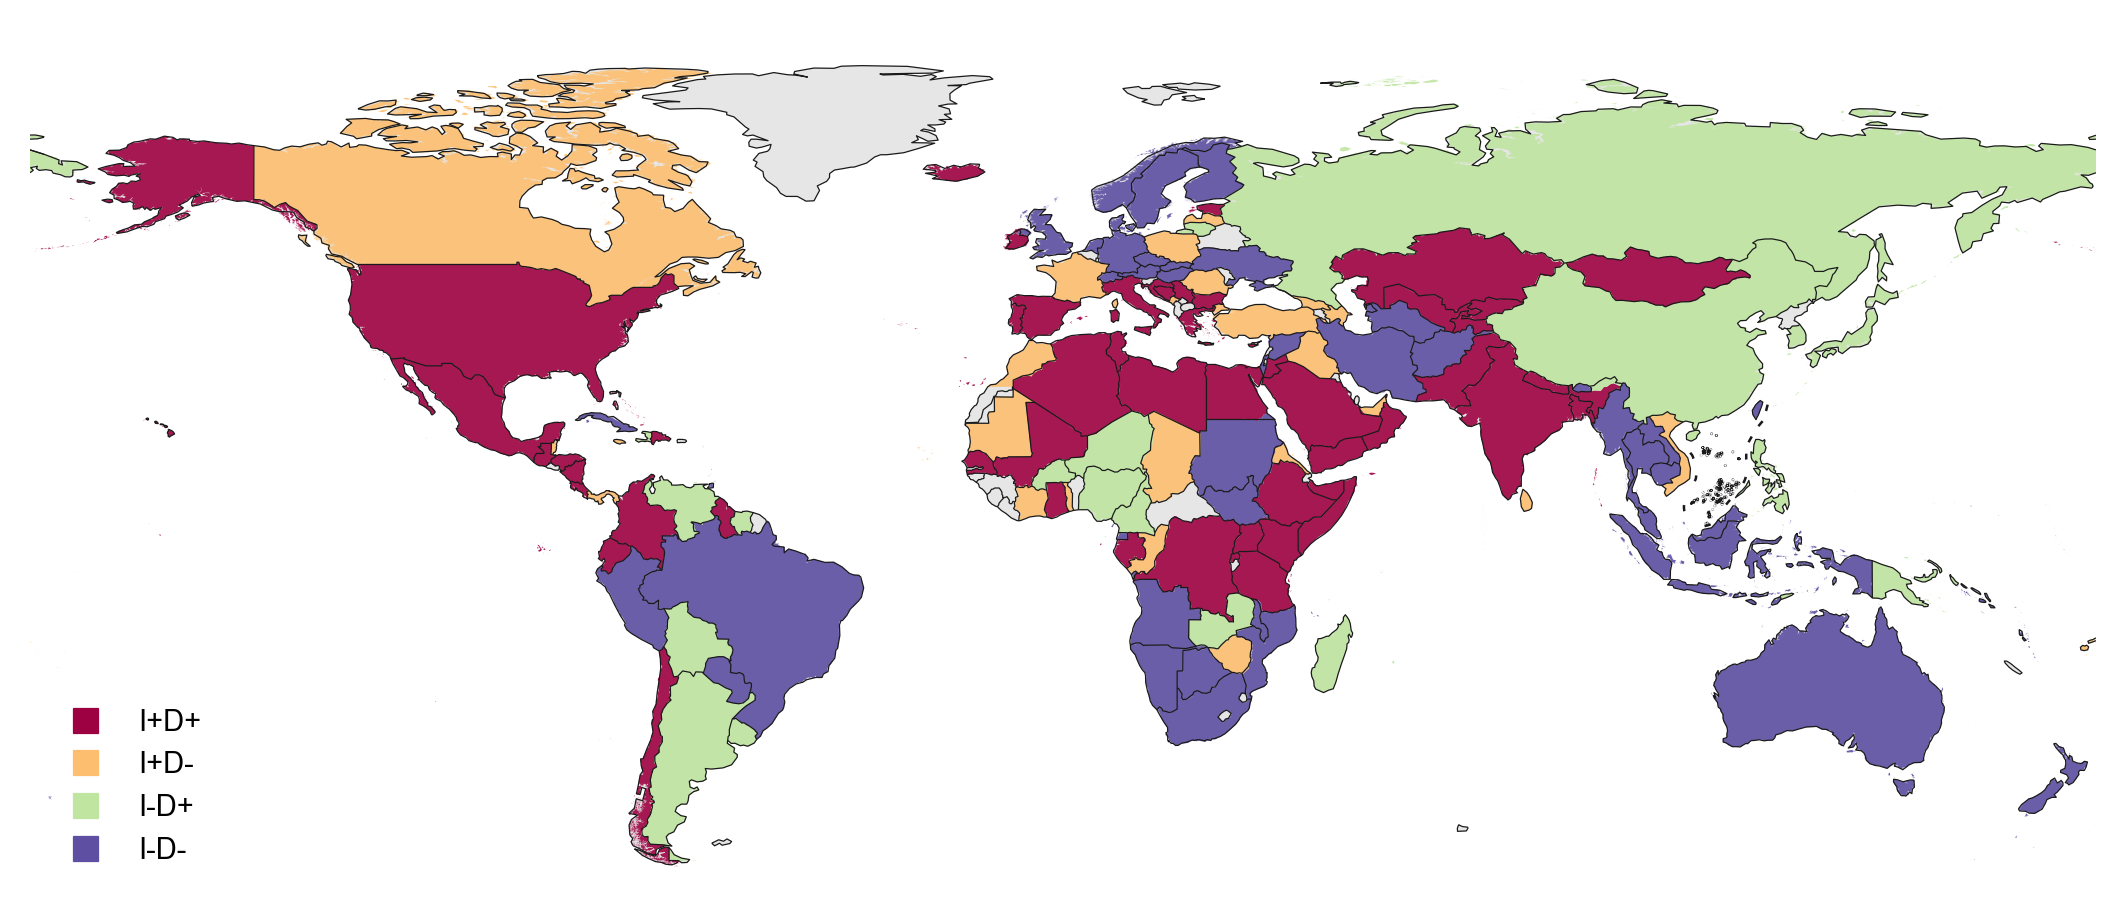

In [410]:
with mpl.rc_context(style):
    fig = plt.figure(layout="constrained", figsize=(18 * cm, (7.5) * cm), dpi=300)
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    cmap = mpl.colormaps["Spectral"].resampled(4)

    adm0_ = adm0.assign(var1=lambda x: x["alpha2"].map(tmp_re["re"].to_dict()))
    handles = []
    for i, c in enumerate(["I+D+", "I+D-", "I-D+", "I-D-"]):
        df_ = adm0_.query("var1 == @c")
        ax.add_geometries(
            df_["geometry"].values,
            crs=ccrs.PlateCarree(),
            facecolor=cmap(i),
            edgecolor="none",
            alpha=0.9,
            rasterized=True,
        )

        handles.append(Line2D([0], [0], label=c, color=cmap(i), marker="s", lw=0))

    ax.add_geometries(cn_south.geometry, crs=ccrs.PlateCarree(), fc='none', ec='.1', lw=.6)
    
    ax.legend(handles=handles, loc="lower left", frameon=False)

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#DCDCDC", alpha=0.7, rasterized=True)

    plt.show()

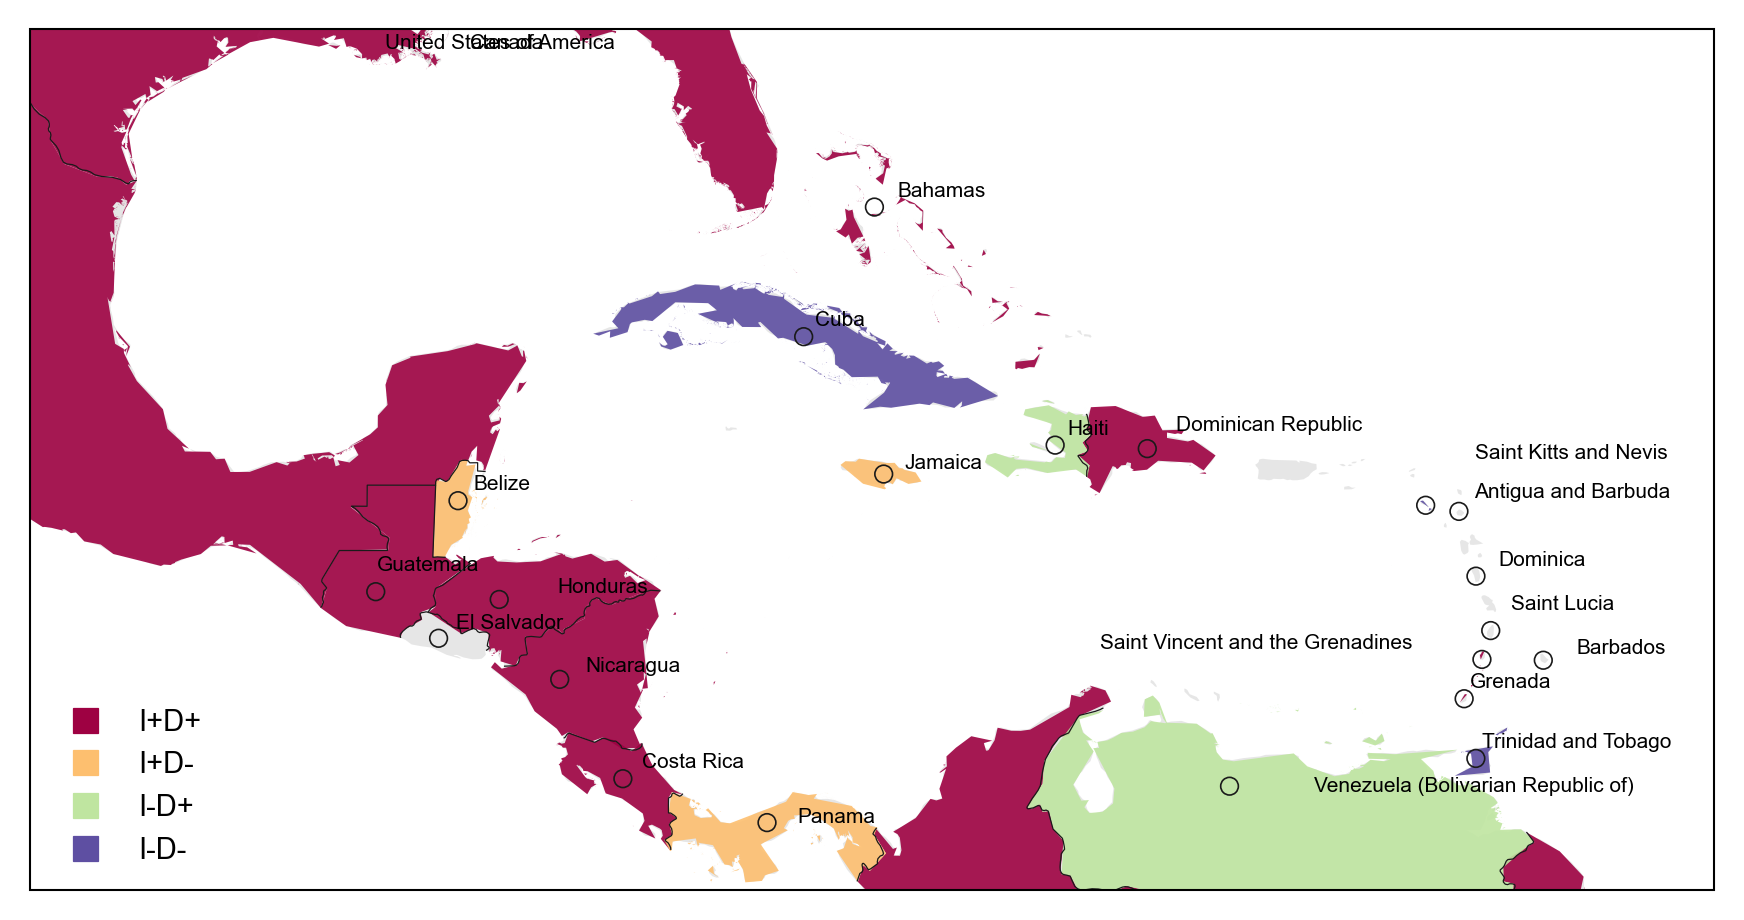

In [ ]:
with mpl.rc_context(style):
    fig = plt.figure(layout="constrained", figsize=(18 * cm, (7.5) * cm), dpi=300)
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    ax.set_extent([-100, -55, 7, 30], crs=ccrs.PlateCarree())
    # ax.set_axis_off()

    adm0_ = adm0.assign(var1=lambda x: x["alpha2"].map(tmp_re["re"].to_dict()))
    handles = []
    for i, c in enumerate(["I+D+", "I+D-", "I-D+", "I-D-"]):
        df_ = adm0_.query("var1 == @c")
        ax.add_geometries(
            df_["geometry"].values,
            crs=ccrs.PlateCarree(),
            facecolor=cmap(i),
            edgecolor="none",
            alpha=0.9,
            rasterized=True,
        )

        handles.append(Line2D([0], [0], label=c, color=cmap(i), marker="s", lw=0))
    ax.legend(handles=handles, loc="lower left", frameon=False)

    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#DCDCDC", alpha=0.7, rasterized=True)

    texts, points = [], []
    for code in countries:
        x, y = country_code_to_lonlat[code]
        if -100 < x < -55 and 7 < y < 55:
            points.append(
                ax.scatter(
                    x,
                    y,
                    s=18,
                    edgecolors=".1",
                    facecolor="none",
                    linewidths=0.4,
                    zorder=99,
                )
            )
            texts.append(ax.text(x, y, alpha2_to_country[code], fontsize=5))

    adjust_text(texts, ax=ax)

    plt.show()

# network

In [414]:
import networkx as nx
from igraph import Graph
from infomap import Infomap

In [415]:
G = nx.from_pandas_edgelist(
    national_traffic_net.query("year == 2019 and type == 'international'"),
    source="dep_country",
    target="arr_country",
    edge_attr=["traffic"],
    create_using=nx.DiGraph,
)

In [416]:
def findCommunity(G):
    im = Infomap(directed=True, silent=True, two_level=True, num_trials=10)
    mapping = im.add_networkx_graph(G, weight="traffic")
    im.run()

    num_modules = im.num_top_modules
    modules = dict(im.modules)
    modules_ = {mapping[k]: v for k, v in im.modules}
    module_members = defaultdict(list)
    for k, v in modules.items():
        module_members[v].append(mapping[k])

    print(f"Found {num_modules} modules with codelength {im.codelength:.8f} bits")
    return module_members

Found 7 modules with codelength 5.38140354 bits
Found 7 modules with codelength 5.43395693 bits


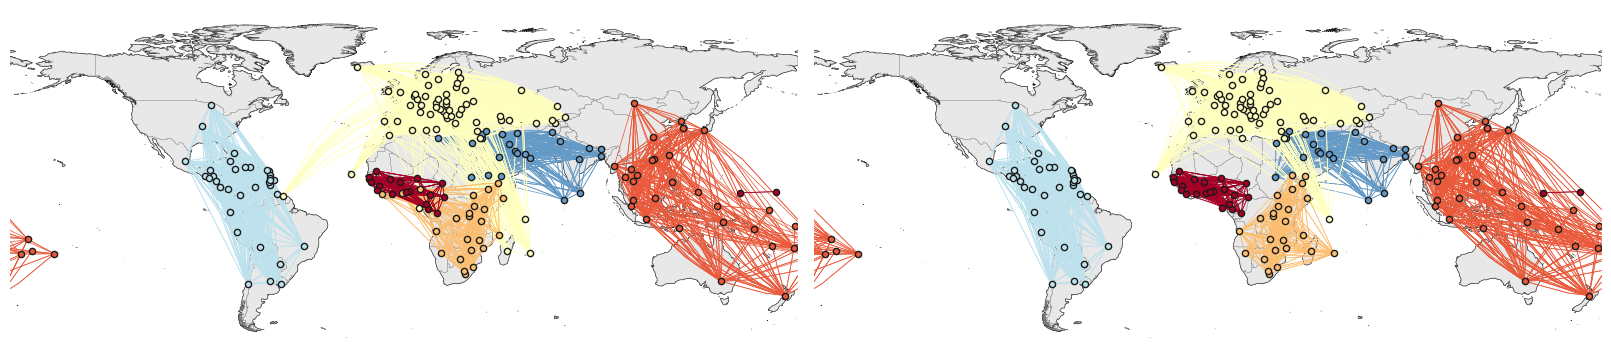

In [417]:
fig = plt.figure(figsize=(16, 8), layout="constrained")

for i, year in enumerate([2011, 2019]):
    ax = plt.subplot(1, 2, i + 1, projection=ccrs.PlateCarree())
    # ax = plt.subplot(1,2,i+1, projection=ccrs.AzimuthalEquidistant(central_latitude=90, central_longitude=0))
    ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())

    tmp = national_traffic_net.query(
        "dep_country in @countries and arr_country in @countries and year == @year and type == 'international' and traffic > 100"
    )
    G = nx.from_pandas_edgelist(
        tmp,
        source="dep_country",
        target="arr_country",
        edge_attr=["traffic"],
        create_using=nx.DiGraph,
    )
    module_members = findCommunity(G)
    national_int_segment_geometry = [
        LineString(
            [
                country_code_to_lonlat[row["dep_country"]],
                country_code_to_lonlat[row["arr_country"]],
            ]
        )
        for _, row in tmp.iterrows()
    ]
    tmp_geo = gpd.GeoDataFrame(
        tmp, geometry=national_int_segment_geometry, crs="EPSG:4326"
    )

    cmap1 = mpl.colormaps["RdYlBu_r"].resampled(len(module_members))

    for k, v in module_members.items():
        tmp_geo_ = tmp_geo[
            (tmp_geo["dep_country"].isin(v)) & (tmp_geo["arr_country"].isin(v))
        ]
        tmp_geo_.sort_values("traffic").plot(
            ax=ax,
            transform=ccrs.Geodetic(),
            lw=0.5,
            color=cmap1(k / len(module_members)),
            zorder=-9,
        )

        a, b = zip(*[country_code_to_lonlat[n] for n in v])
        ax.scatter(a, b, s=20, ec=".1", fc=cmap1(k / len(module_members)), zorder=0)

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5, zorder=-99)
    fplt.add_countries(ax=ax, ls="-", fc="none", ec=".1", lw=0.2, zorder=-99)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5, zorder=-99)
    ax.set_axis_off()

plt.show()

Found 7 modules with codelength 5.43395693 bits
Found 8 modules with codelength 5.38723661 bits


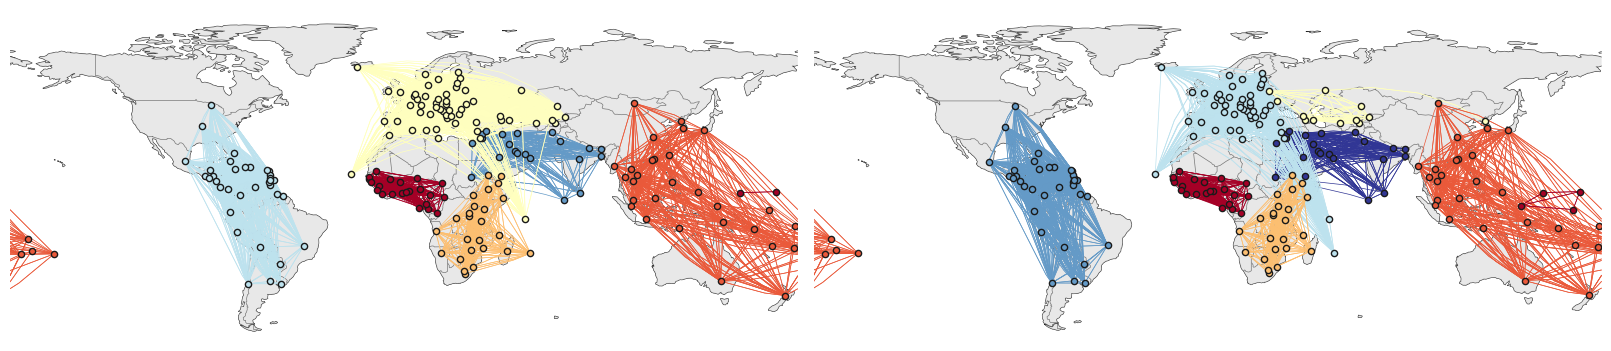

In [418]:
fig = plt.figure(figsize=(16, 8), layout="constrained")

for i, year in enumerate([2019, 2024]):
    ax = plt.subplot(1, 2, i + 1, projection=ccrs.PlateCarree())
    # ax = plt.subplot(1,2,i+1, projection=ccrs.AzimuthalEquidistant(central_latitude=90, central_longitude=0))
    ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())

    tmp = national_traffic_net.query(
        "dep_country in @countries and arr_country in @countries and year == @year and type == 'international' and traffic > 100"
    )
    G = nx.from_pandas_edgelist(
        tmp,
        source="dep_country",
        target="arr_country",
        edge_attr=["traffic"],
        create_using=nx.DiGraph,
    )
    module_members = findCommunity(G)
    national_int_segment_geometry = [
        LineString(
            [
                country_code_to_lonlat[row["dep_country"]],
                country_code_to_lonlat[row["arr_country"]],
            ]
        )
        for _, row in tmp.iterrows()
    ]
    tmp_geo = gpd.GeoDataFrame(
        tmp, geometry=national_int_segment_geometry, crs="EPSG:4326"
    )

    for k, v in module_members.items():
        # if len(v)<10:
        #     continue

        tmp_geo_ = tmp_geo[
            (tmp_geo["dep_country"].isin(v)) & (tmp_geo["arr_country"].isin(v))
        ]
        tmp_geo_.sort_values("traffic").plot(
            ax=ax,
            transform=ccrs.Geodetic(),
            lw=0.5,
            color=cmap1(k / len(module_members)),
            zorder=-9,
        )

        a, b = zip(*[country_code_to_lonlat[n] for n in v])
        ax.scatter(a, b, s=20, ec=".1", fc=cmap1(k / len(module_members)), zorder=0)

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5, zorder=-99)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.5, zorder=-99)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5, zorder=-99)
    ax.set_axis_off()

plt.show()


In [419]:
tmp_2019 = national_traffic_net.query(
    "dep_country in @countries and arr_country in @countries and year == 2019 and type == 'international' and traffic > 100"
)
G_2019 = nx.from_pandas_edgelist(
    tmp_2019,
    source="dep_country",
    target="arr_country",
    edge_attr=["traffic"],
    create_using=nx.DiGraph,
)
module_members_2019 = findCommunity(G_2019)

tmp_2024 = national_traffic_net.query(
    "dep_country in @countries and arr_country in @countries and year == 2024 and type == 'international' and traffic > 100"
)
G_2024 = nx.from_pandas_edgelist(
    tmp_2024,
    source="dep_country",
    target="arr_country",
    edge_attr=["traffic"],
    create_using=nx.DiGraph,
)
module_members_2024 = findCommunity(G_2024)

Found 7 modules with codelength 5.43395693 bits
Found 8 modules with codelength 5.38723661 bits
Found 8 modules with codelength 5.38723661 bits


In [420]:
cc = pd.DataFrame(
    {
        "c2019": dict([(v_i, k) for k, v in module_members_2019.items() for v_i in v]),
        "c2024": dict([(v_i, k) for k, v in module_members_2024.items() for v_i in v]),
    }
)

cc["c2019_"] = cc["c2019"].map(lambda x: x + 1 if x >= 5 else x)
cc["c2024_"] = cc["c2024"]  # .map(lambda x: x+10)

cc["c2019_1"] = cc["c2019_"].map(lambda x: f"c2019_{int(x)}")
cc["c2024_1"] = cc["c2024_"].map(lambda x: f"c2024_{int(x)}")

In [421]:
ccc = cc.groupby(["c2019_1", "c2024_1"]).size().reset_index()
nodes = np.sort(np.hstack([ccc["c2019_1"].unique(), ccc["c2024_1"].unique()])).tolist()

ccc["c2019_2"] = ccc["c2019_1"].map(lambda x: nodes.index(x))
ccc["c2024_2"] = ccc["c2024_1"].map(lambda x: nodes.index(x))

ccc

,c2019_1,c2024_1,0,c2019_2,c2024_2
0,c2019_1,c2024_1,21,0,7
1,c2019_2,c2024_2,35,1,8
2,c2019_3,c2024_3,46,2,9
3,c2019_3,c2024_4,11,2,10
4,c2019_4,c2024_1,1,3,7
5,c2019_4,c2024_3,1,3,9
6,c2019_4,c2024_5,23,3,11
7,c2019_6,c2024_4,1,4,10
8,c2019_6,c2024_6,30,4,12
9,c2019_6,c2024_8,2,4,14


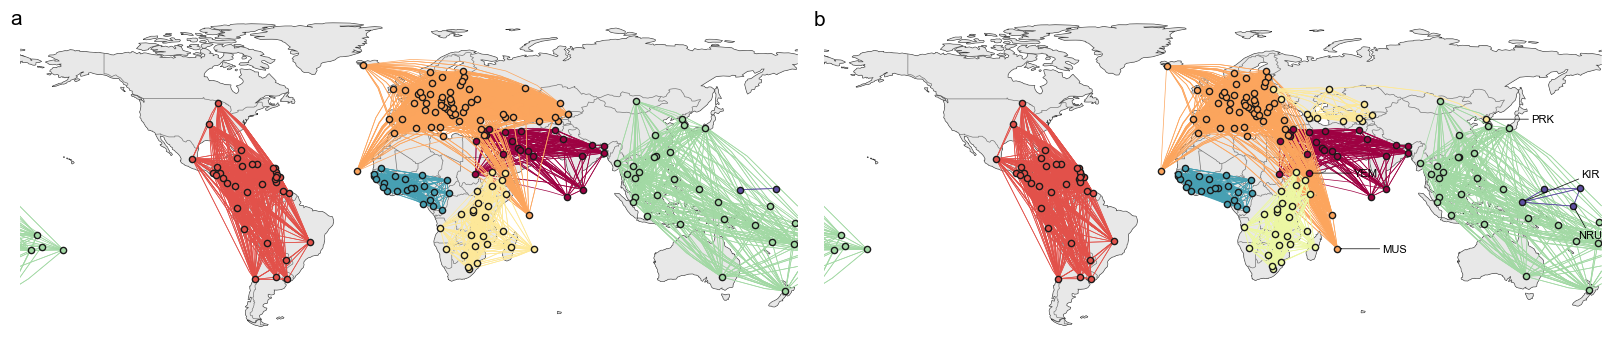

In [422]:
fig = plt.figure(figsize=(16, 8), layout="constrained")

ax = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax.text(
    0.0,
    1.0,
    "a",
    fontsize=15,
    transform=(ax.transAxes + ScaledTranslation(-7 / 72, 0 / 72, fig.dpi_scale_trans)),
    va="top",
)

ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
national_int_segment_geometry = [
    LineString(
        [
            country_code_to_lonlat[row["dep_country"]],
            country_code_to_lonlat[row["arr_country"]],
        ]
    )
    for _, row in tmp_2019.iterrows()
]
tmp_geo = gpd.GeoDataFrame(
    tmp_2019, geometry=national_int_segment_geometry, crs="EPSG:4326"
)

for k, color in zip(
    [1, 2, 3, 4, 5, 6, 7],
    ["#9e0142", "#e2514a", "#fca55d", "#fee999", "#a2d9a4", "#47a0b3", "#5e4fa2"],
):
    v = module_members_2019[k]
    tmp_geo_ = tmp_geo[
        (tmp_geo["dep_country"].isin(v)) & (tmp_geo["arr_country"].isin(v))
    ]
    tmp_geo_.sort_values("traffic").plot(
        ax=ax, transform=ccrs.Geodetic(), lw=0.5, color=color, zorder=-9
    )

    a, b = zip(*[country_code_to_lonlat[n] for n in v])
    ax.scatter(a, b, s=20, ec=".1", fc=color, zorder=0)

ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5, zorder=-99)
ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.5, zorder=-99)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5, zorder=-99)
ax.set_axis_off()


ax = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax.text(
    0.0,
    1.0,
    "b",
    fontsize=15,
    transform=(ax.transAxes + ScaledTranslation(-7 / 72, 0 / 72, fig.dpi_scale_trans)),
    va="top",
)

ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
national_int_segment_geometry = [
    LineString(
        [
            country_code_to_lonlat[row["dep_country"]],
            country_code_to_lonlat[row["arr_country"]],
        ]
    )
    for _, row in tmp_2024.iterrows()
]
tmp_geo = gpd.GeoDataFrame(
    tmp_2024, geometry=national_int_segment_geometry, crs="EPSG:4326"
)

for k, color in zip(
    [1, 2, 3, 4, 5, 6, 7, 8],
    [
        "#9e0142",
        "#e2514a",
        "#fca55d",
        "#fee999",
        "#edf8a3",
        "#a2d9a4",
        "#47a0b3",
        "#5e4fa2",
    ],
):
    v = module_members_2024[k]
    tmp_geo_ = tmp_geo[
        (tmp_geo["dep_country"].isin(v)) & (tmp_geo["arr_country"].isin(v))
    ]
    tmp_geo_.sort_values("traffic").plot(
        ax=ax, transform=ccrs.Geodetic(), lw=0.5, color=color, zorder=-9
    )

    a, b = zip(*[country_code_to_lonlat[n] for n in v])
    ax.scatter(a, b, s=20, ec=".1", fc=color, zorder=0)

ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5, zorder=-99)
ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.5, zorder=-99)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5, zorder=-99)


texts = [
    ax.text(
        *country_code_to_lonlat[c],
        iso2_to_iso3[c],
        fontsize=8,
        transform=ccrs.PlateCarree(),
        va="center",
    )
    for c in ["KP", "KI", "NR", "MU", "YE"]
]
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color="k", lw=0.5),
    ax=ax,
    force_static=(3.5, 3.5),
    force_explode=(5, 3),
    expand=(2.1, 5),
)


ax.set_axis_off()


plt.show()